0.05


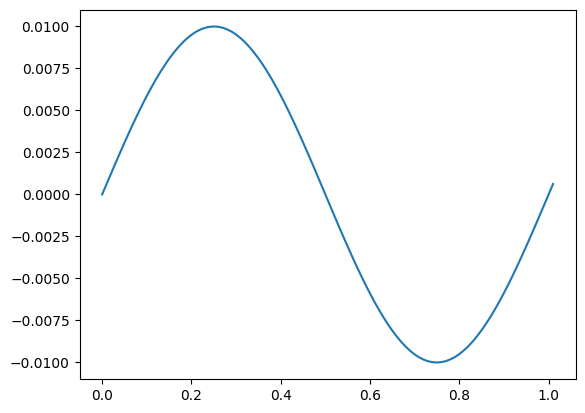

0.1


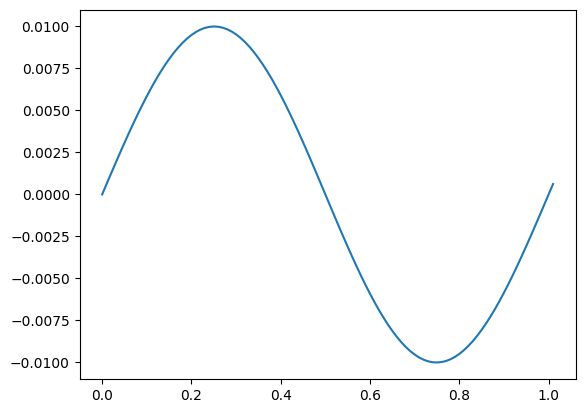

0.15000000000000002


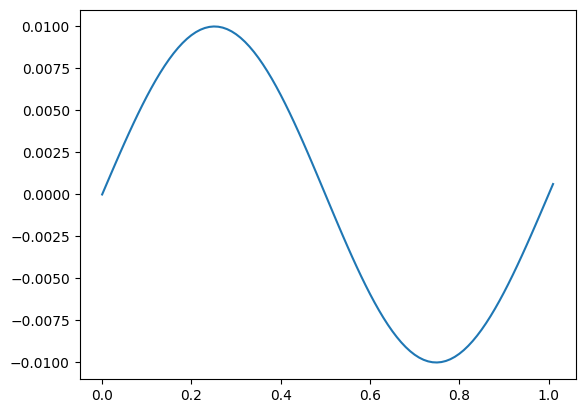

0.2


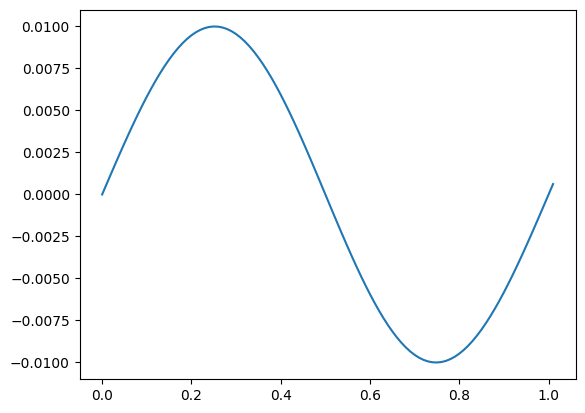

0.25


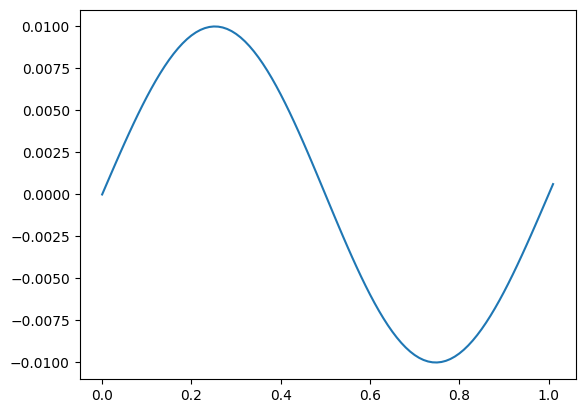

0.3


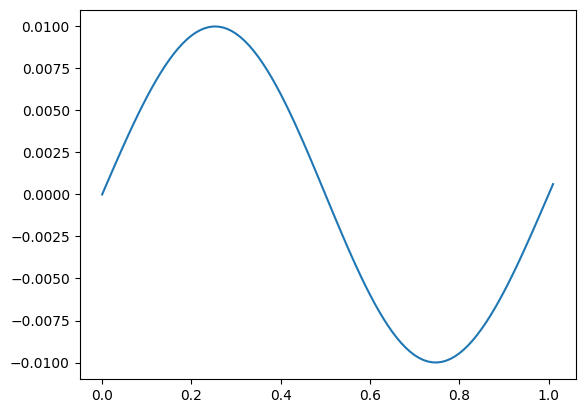

0.35


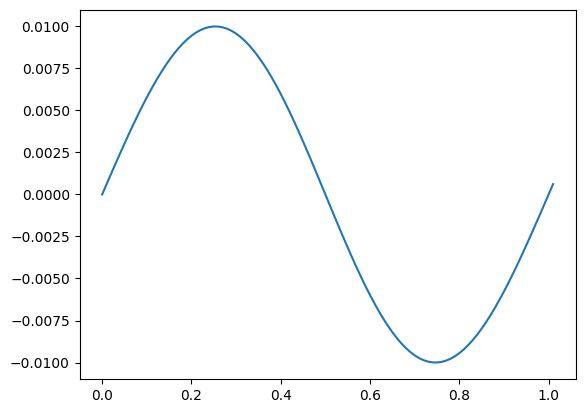

0.39999999999999997


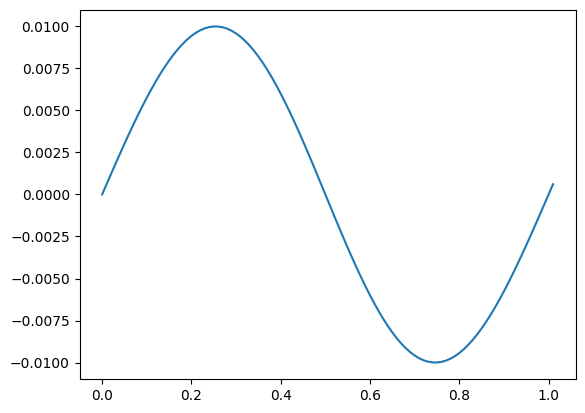

0.44999999999999996


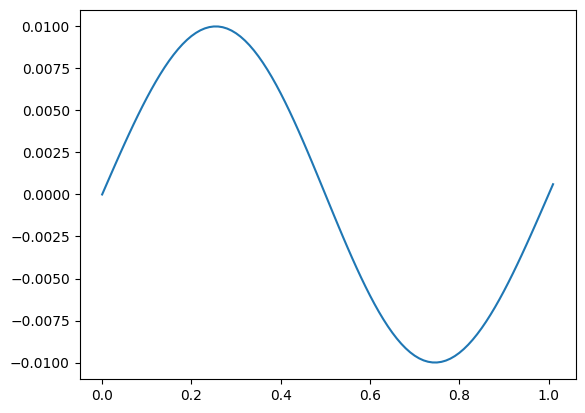

0.49999999999999994


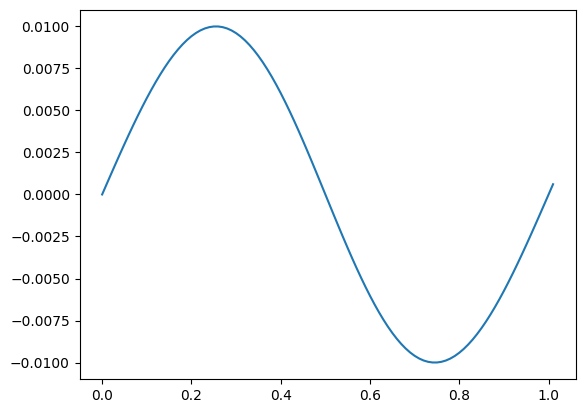

0.5499999999999999


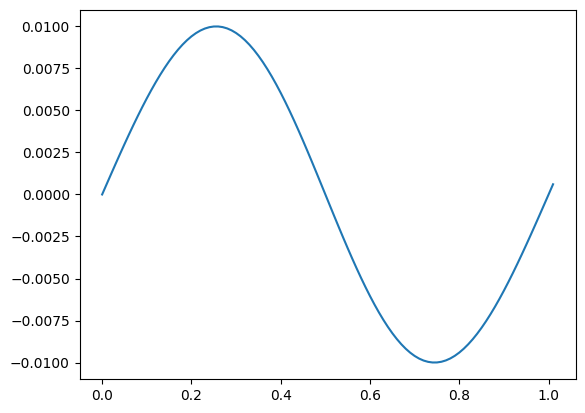

0.6


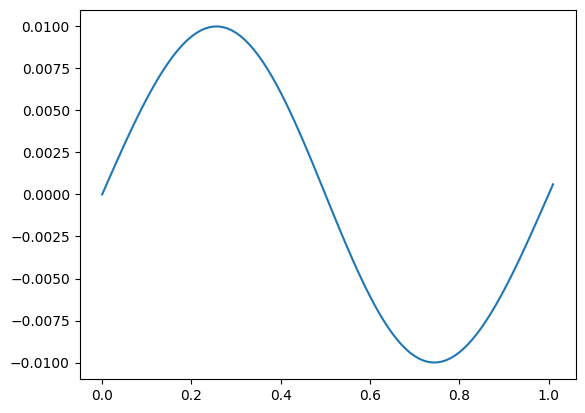

0.65


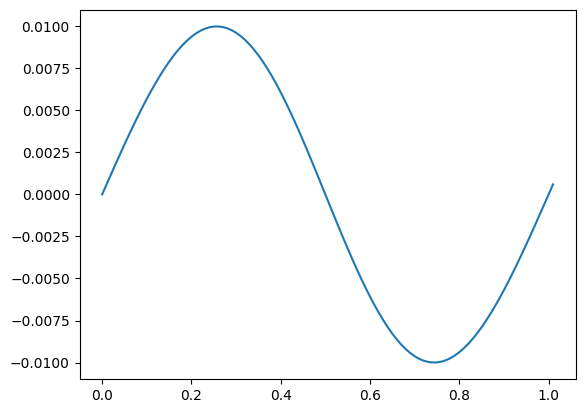

0.7000000000000001


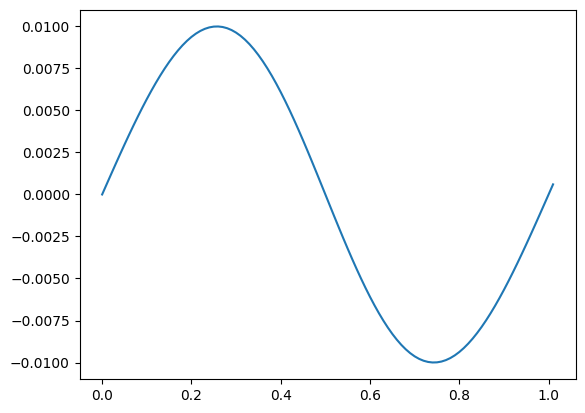

0.7500000000000001


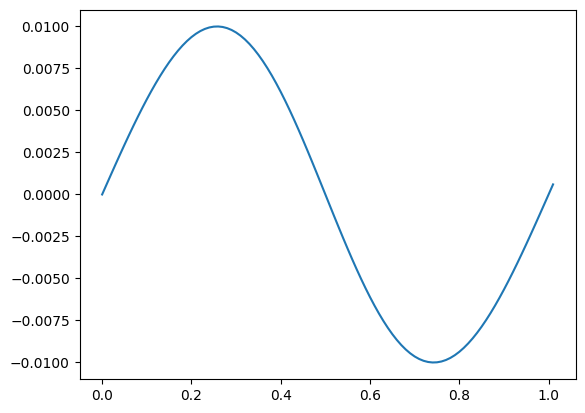

0.8000000000000002


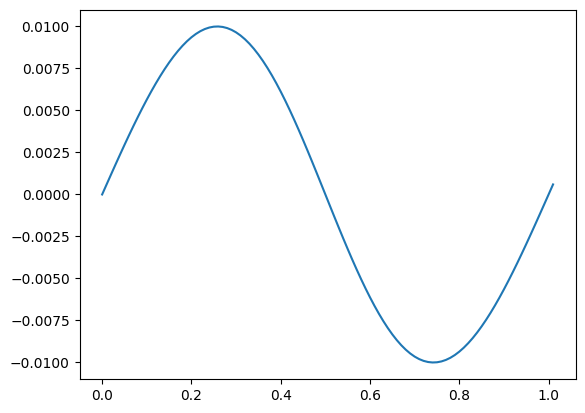

0.8500000000000002


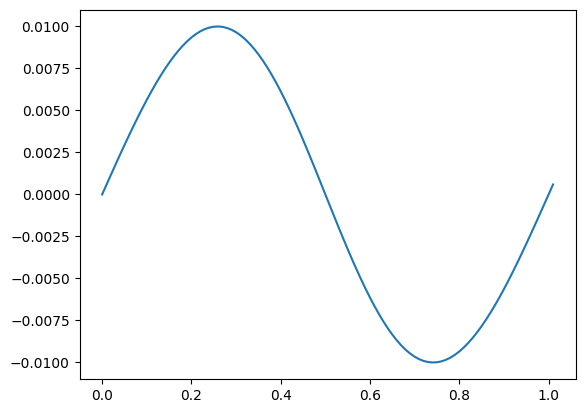

0.9000000000000002


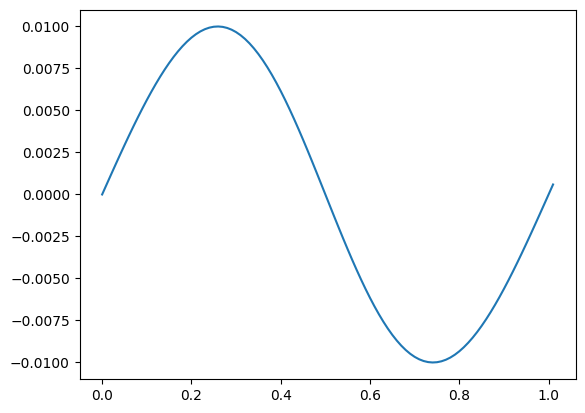

0.9500000000000003


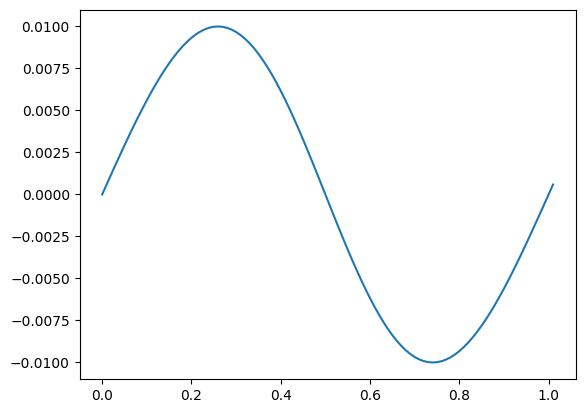

1.0000000000000002


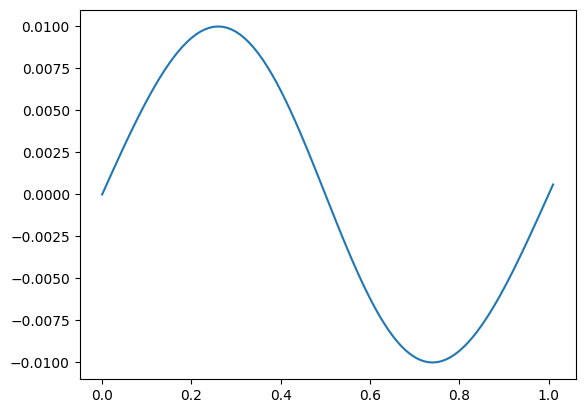

1.0500000000000003


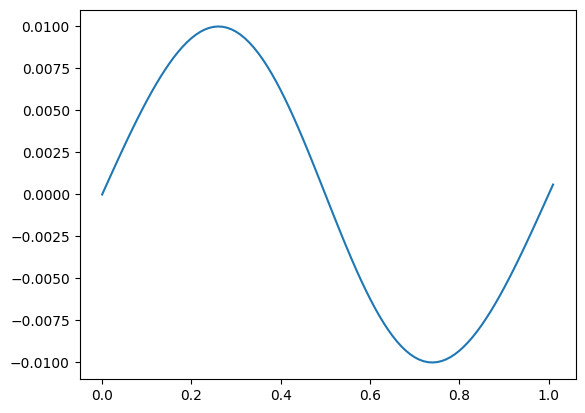

1.1000000000000003


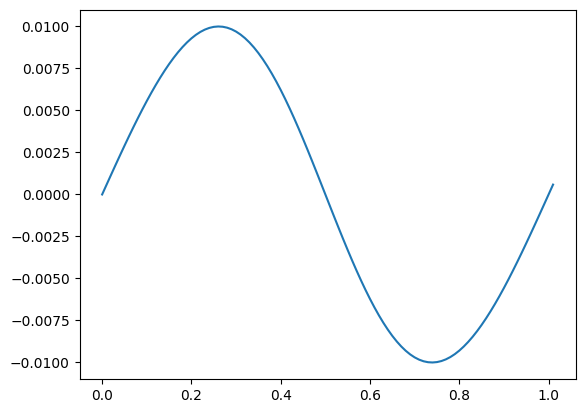

1.1500000000000004


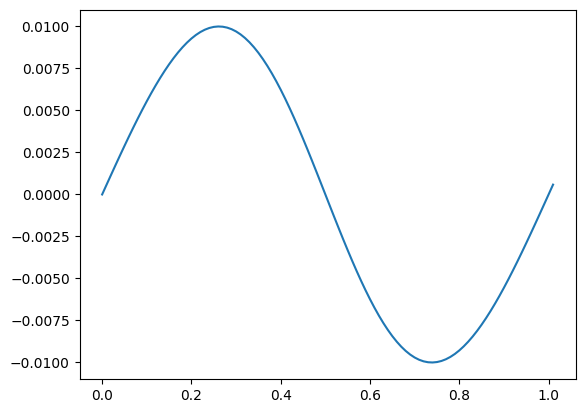

1.2000000000000004


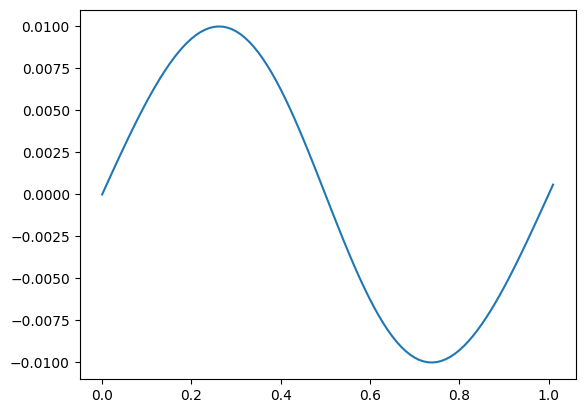

1.2500000000000004


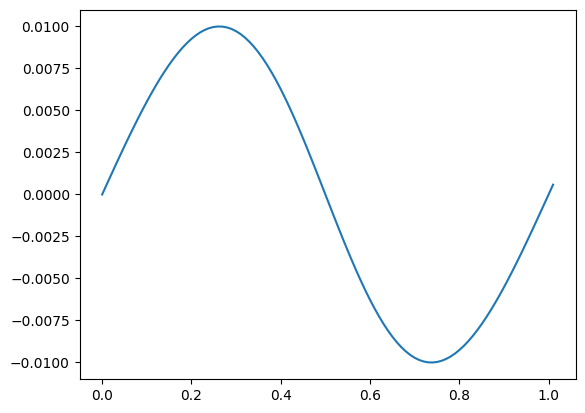

1.3000000000000005


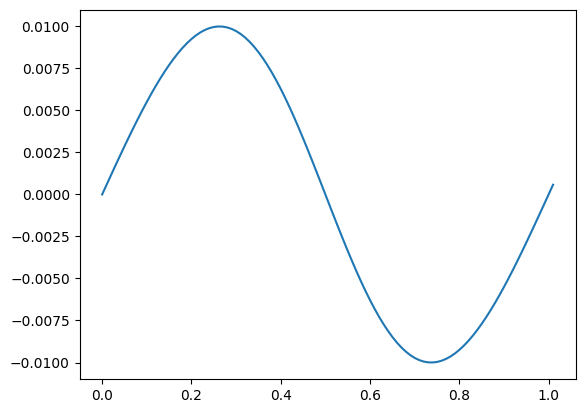

1.3500000000000005


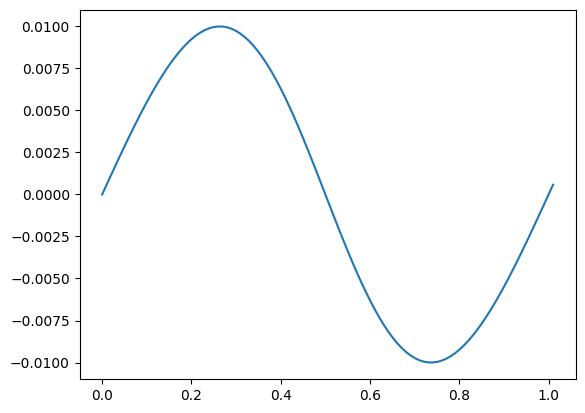

1.4000000000000006


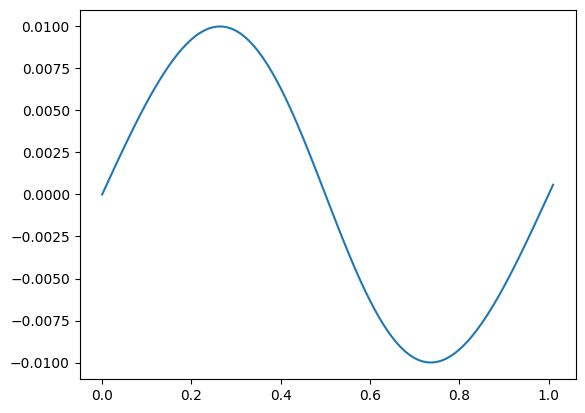

1.4500000000000006


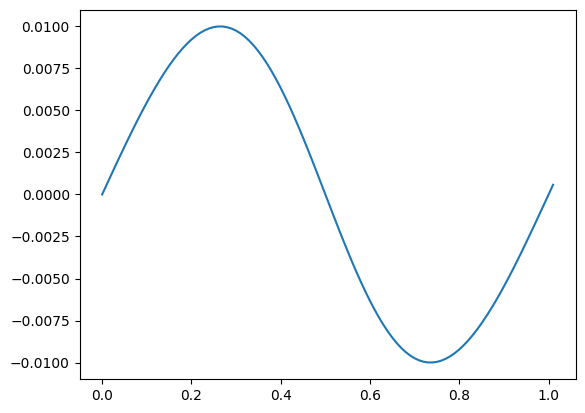

1.5000000000000007


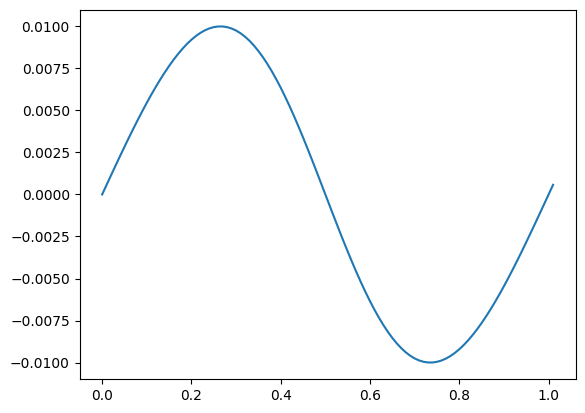

1.5500000000000007


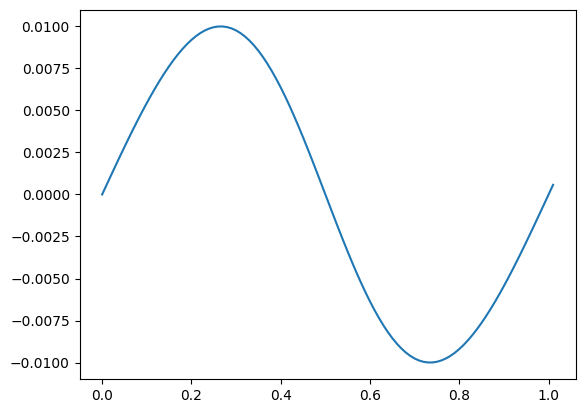

1.6000000000000008


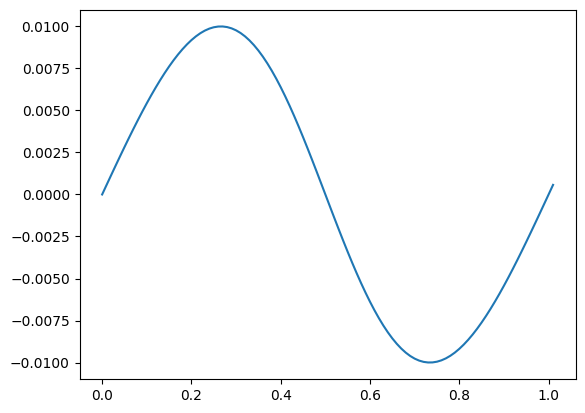

1.6500000000000008


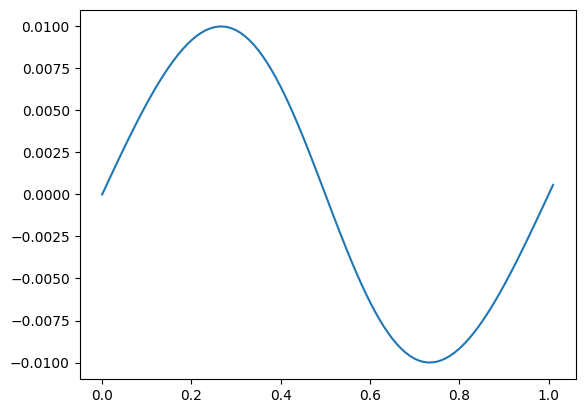

1.7000000000000008


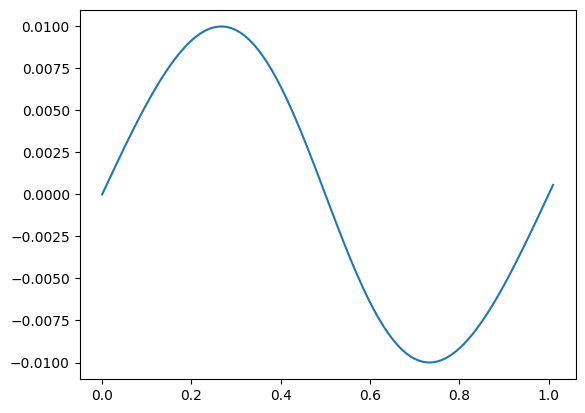

1.7500000000000009


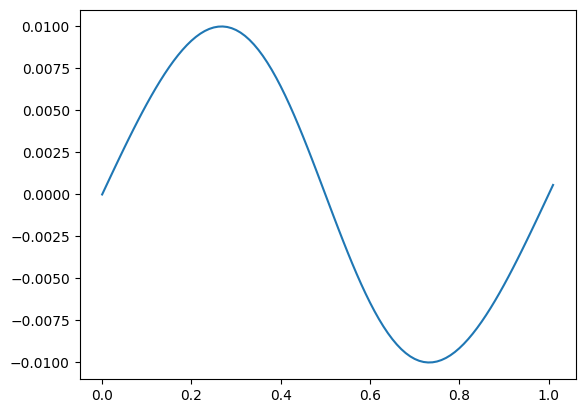

1.800000000000001


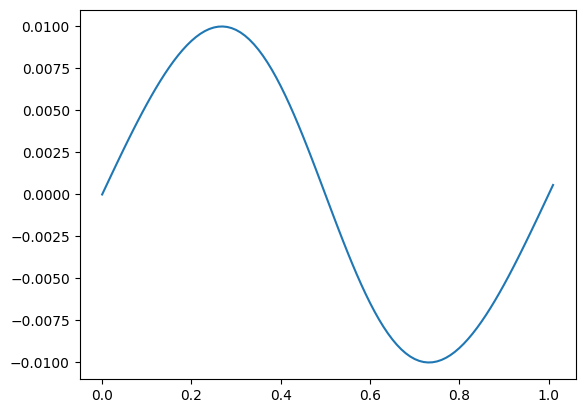

1.850000000000001


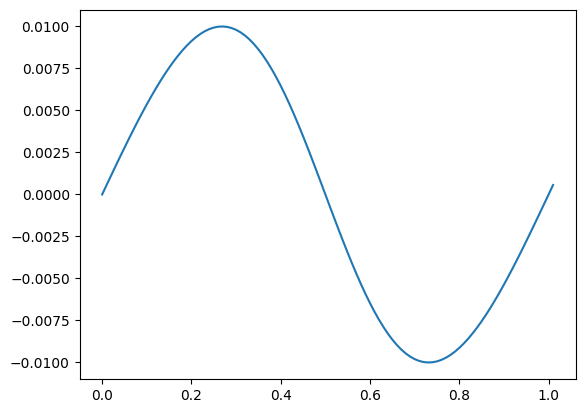

1.900000000000001


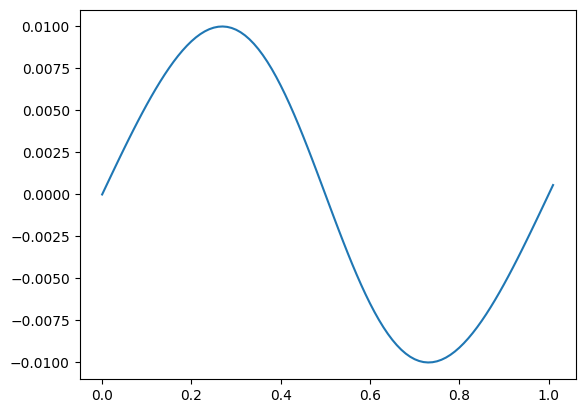

1.950000000000001


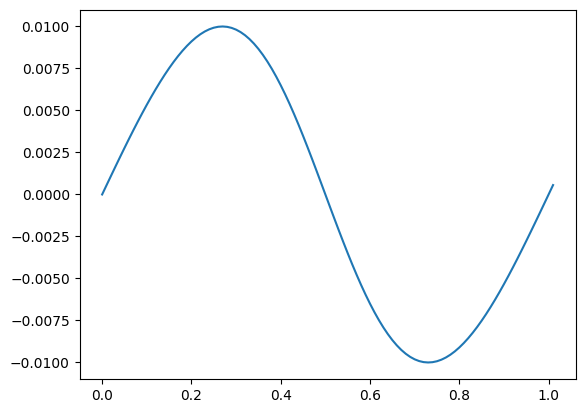

2.000000000000001


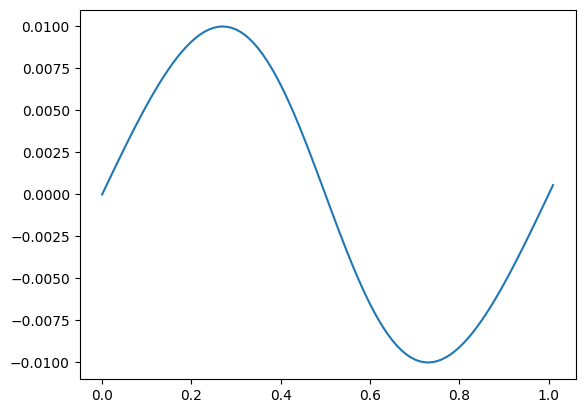

2.0500000000000007


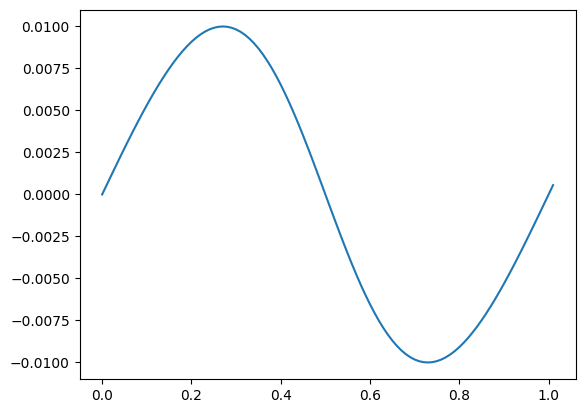

2.1000000000000005


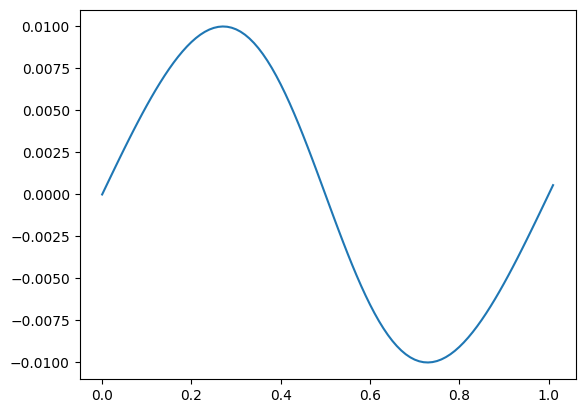

2.1500000000000004


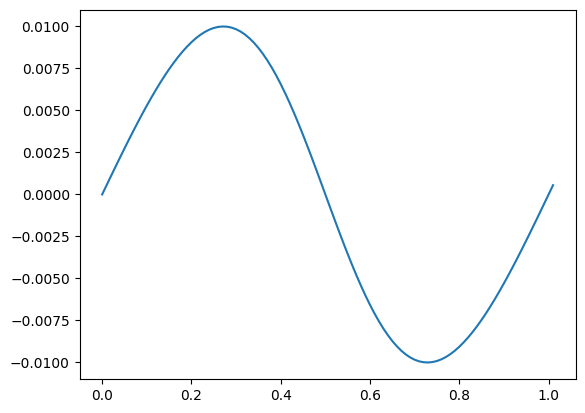

2.2


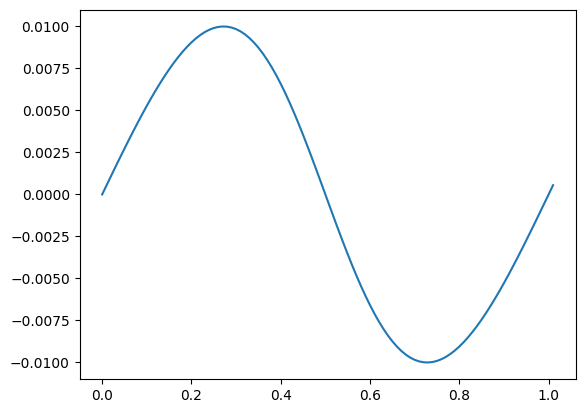

2.25


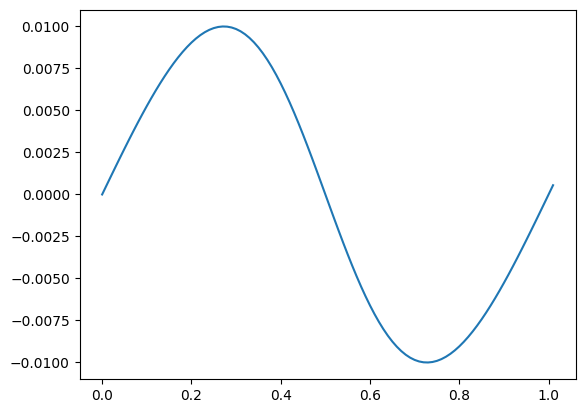

2.3


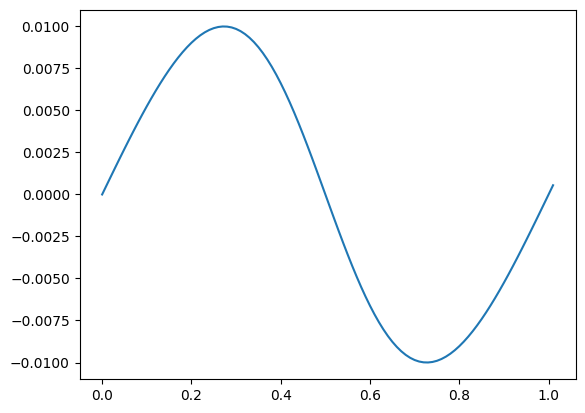

2.3499999999999996


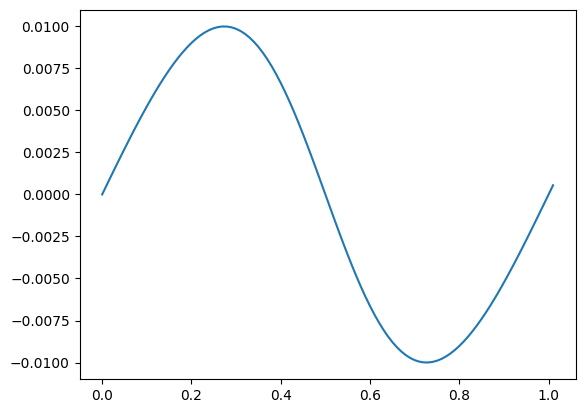

2.3999999999999995


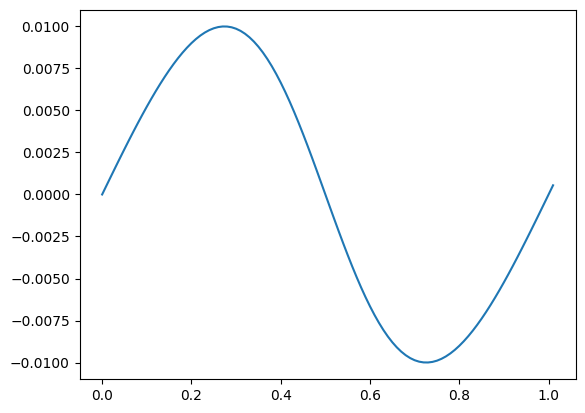

2.4499999999999993


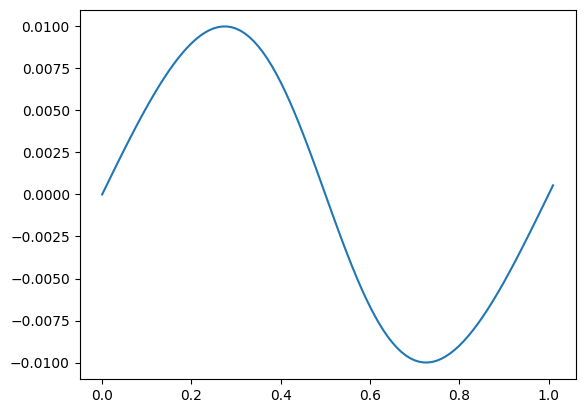

2.499999999999999


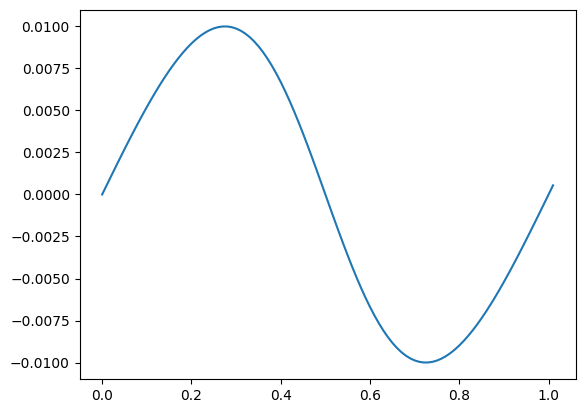

2.549999999999999


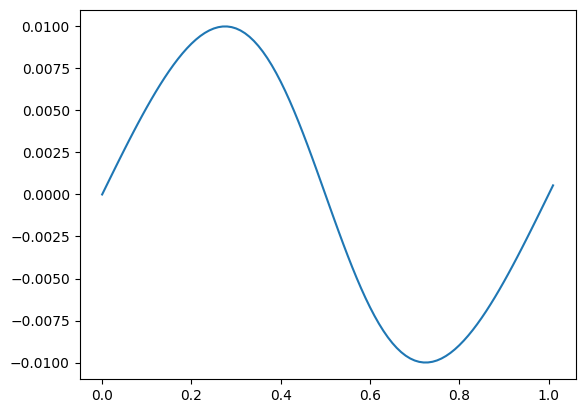

2.5999999999999988


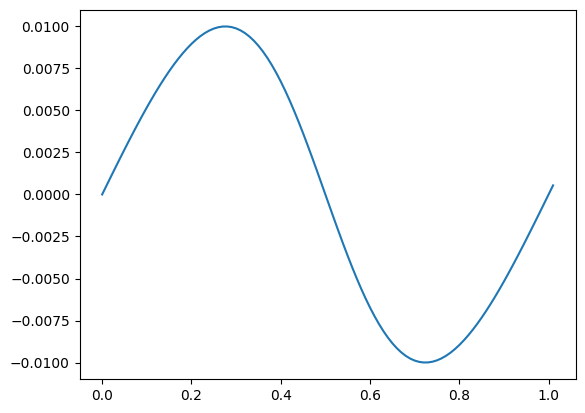

2.6499999999999986


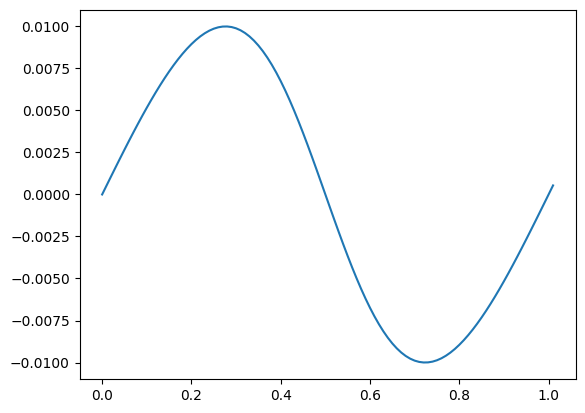

2.6999999999999984


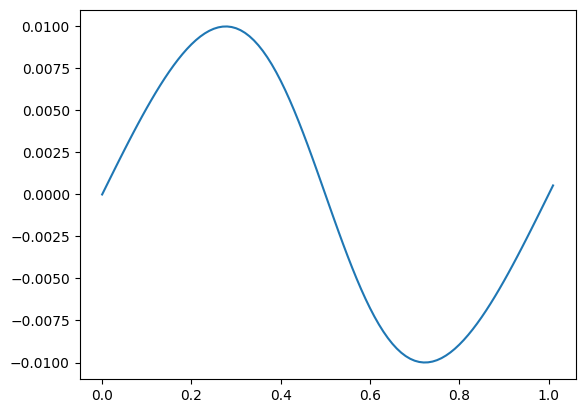

2.7499999999999982


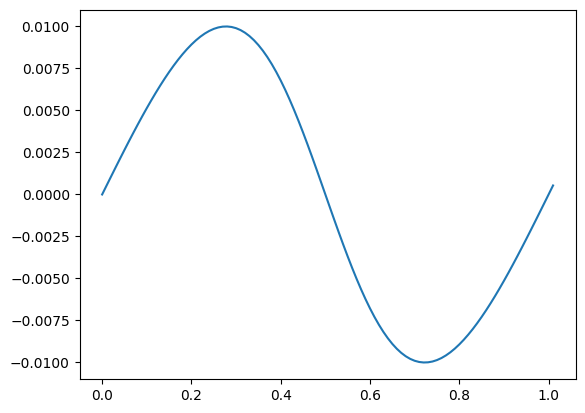

2.799999999999998


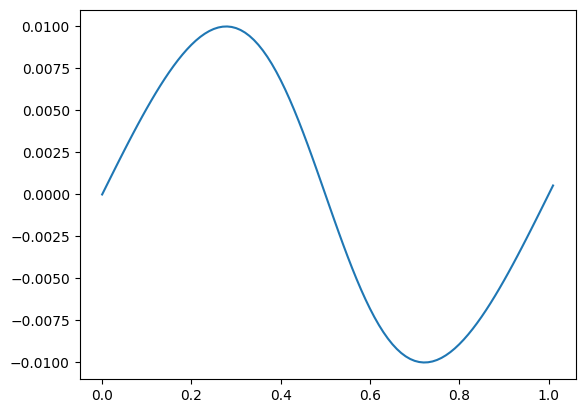

2.849999999999998


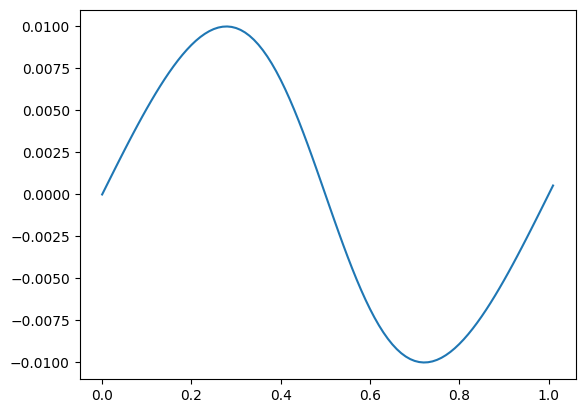

2.8999999999999977


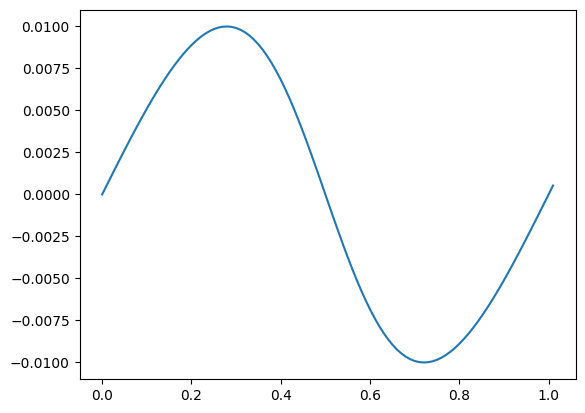

2.9499999999999975


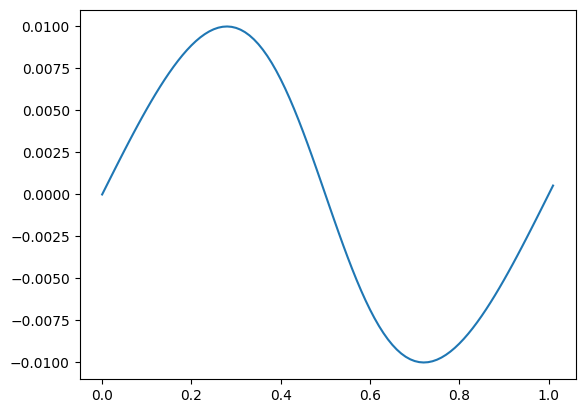

2.9999999999999973


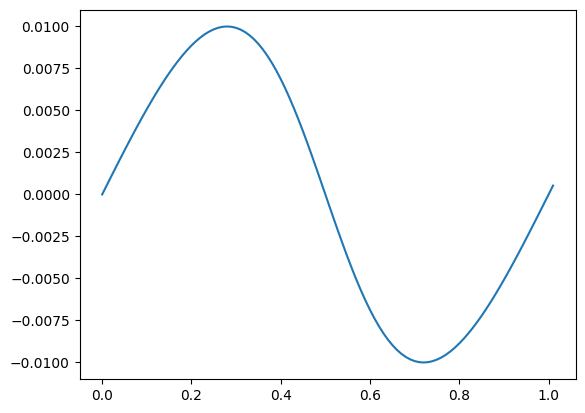

3.049999999999997


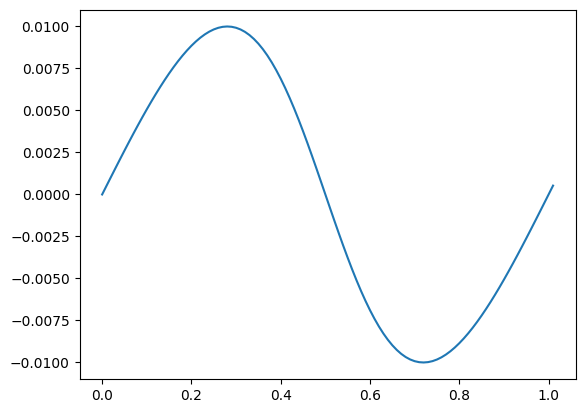

3.099999999999997


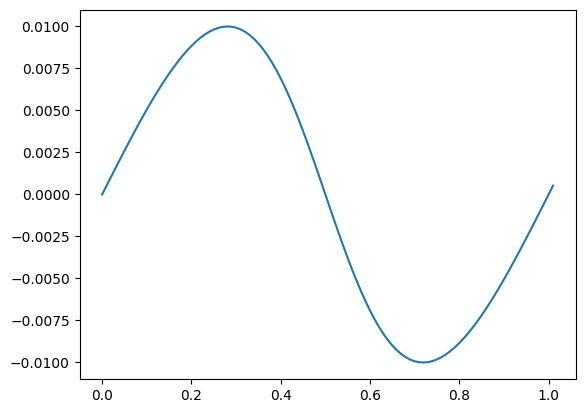

3.149999999999997


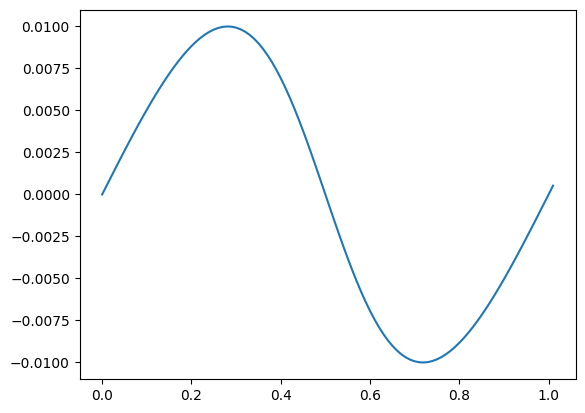

3.1999999999999966


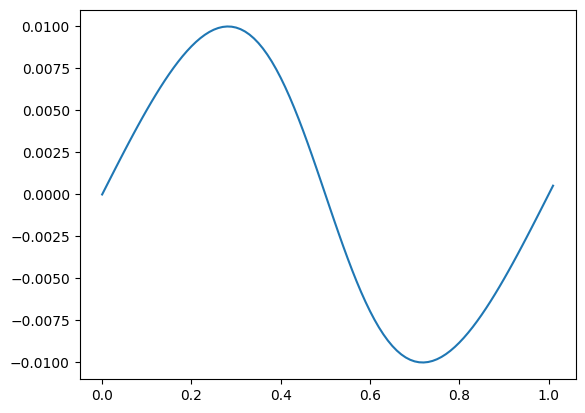

3.2499999999999964


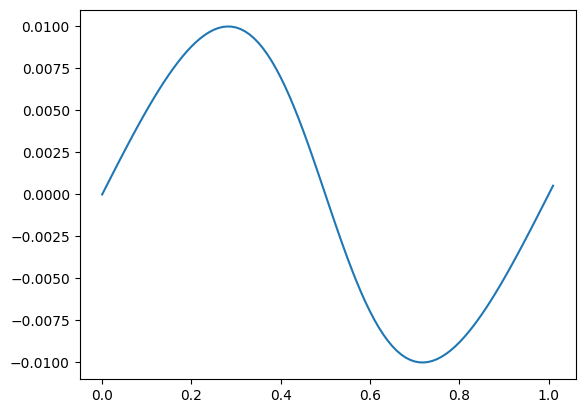

3.2999999999999963


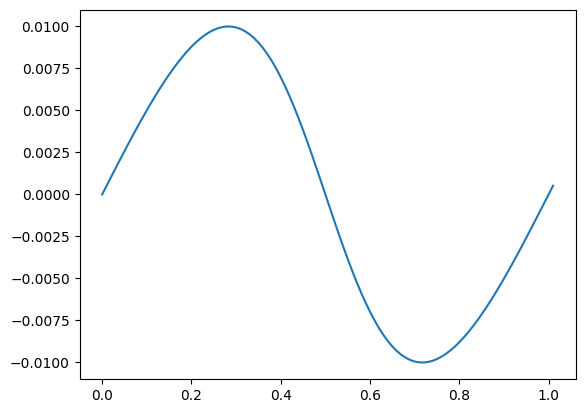

3.349999999999996


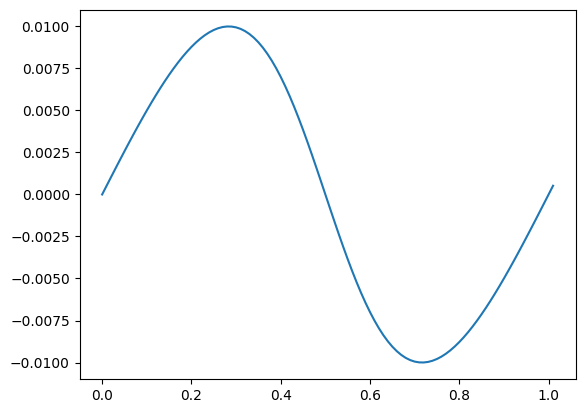

3.399999999999996


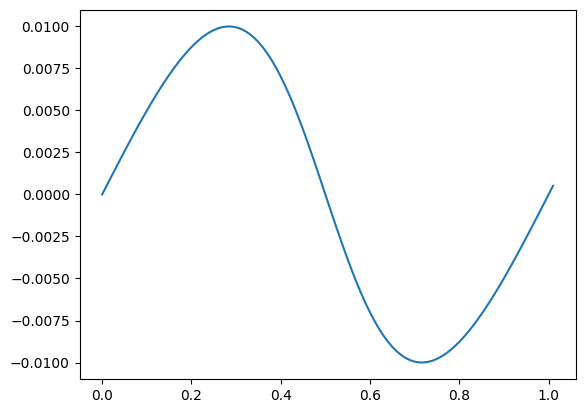

3.4499999999999957


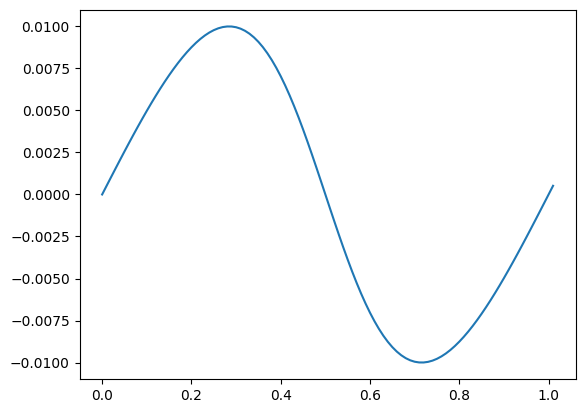

3.4999999999999956


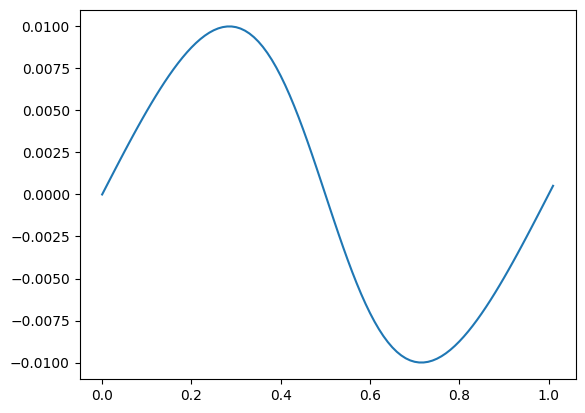

3.5499999999999954


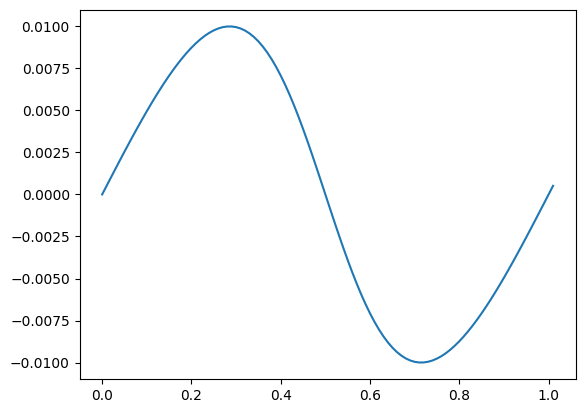

3.599999999999995


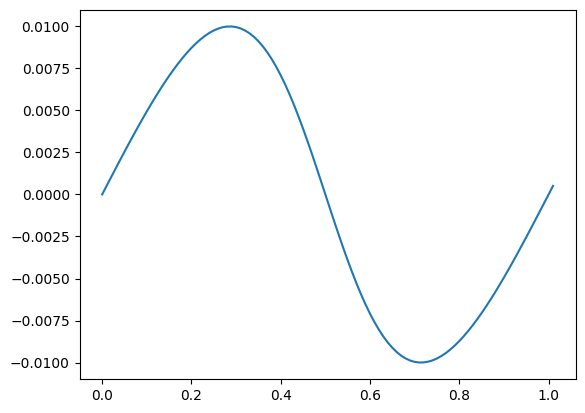

3.649999999999995


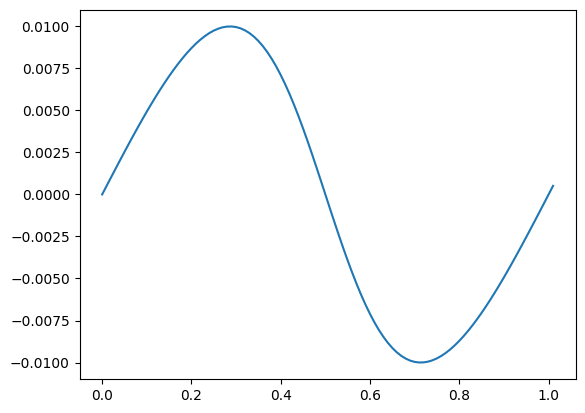

3.699999999999995


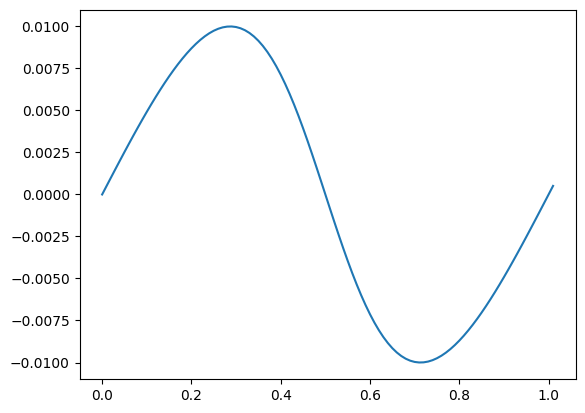

3.7499999999999947


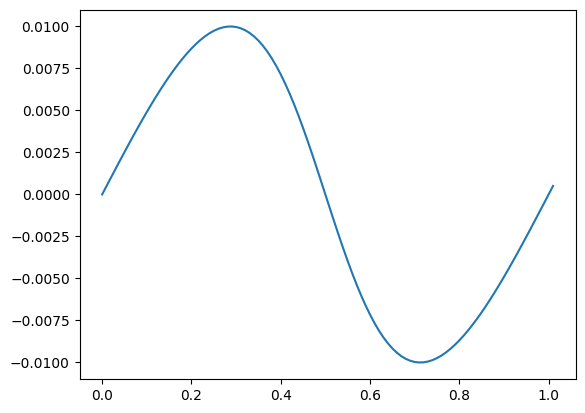

3.7999999999999945


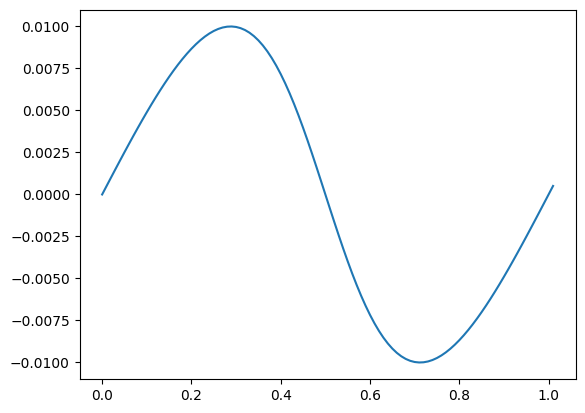

3.8499999999999943


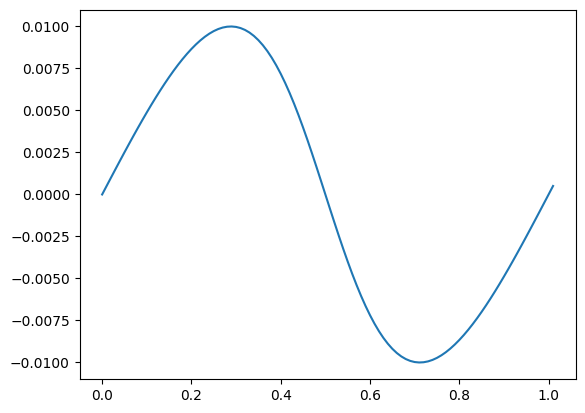

3.899999999999994


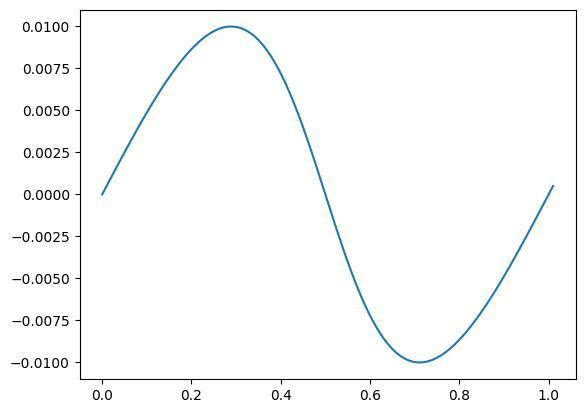

3.949999999999994


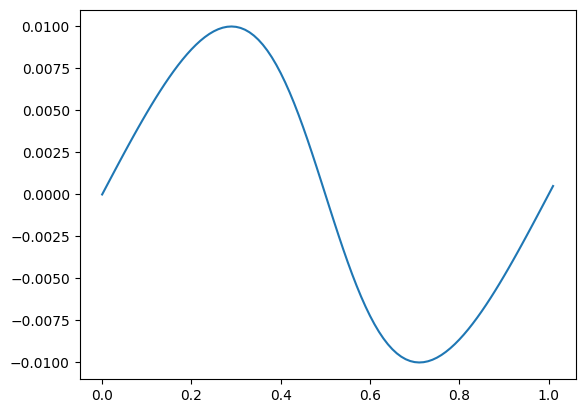

3.999999999999994


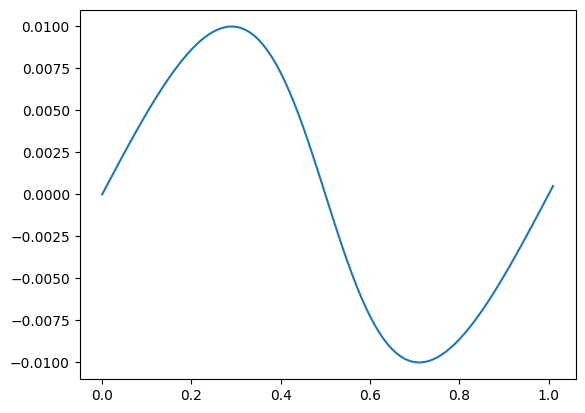

4.049999999999994


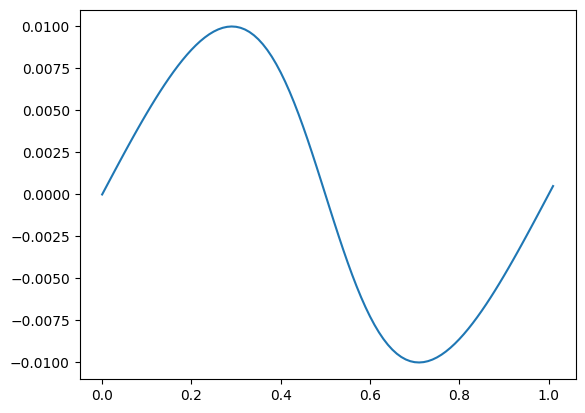

4.099999999999993


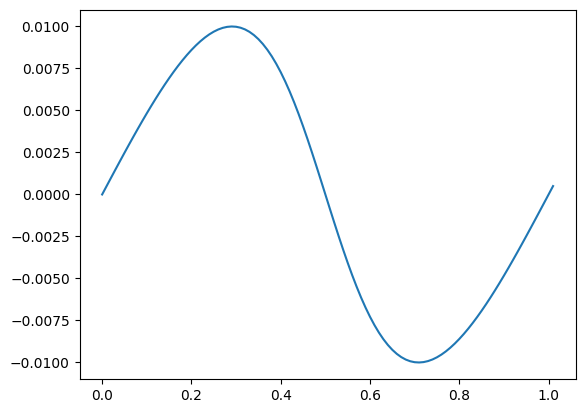

4.149999999999993


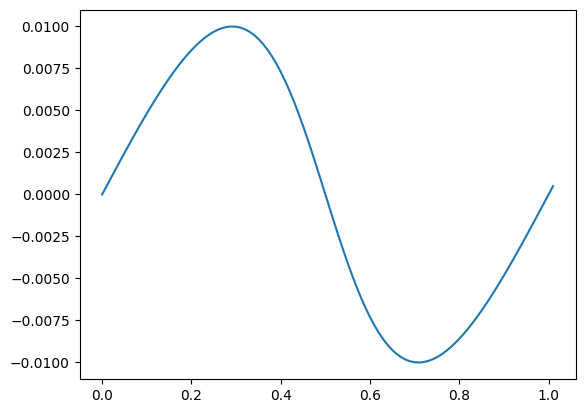

4.199999999999993


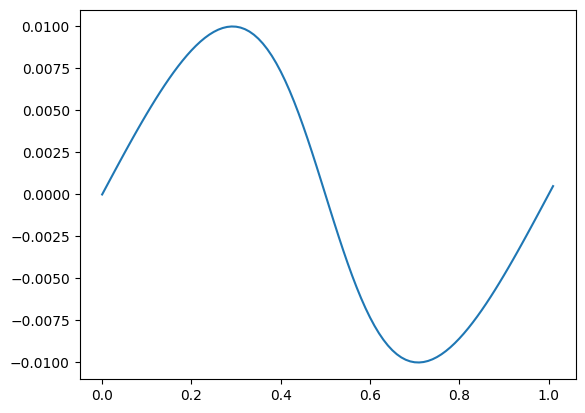

4.249999999999993


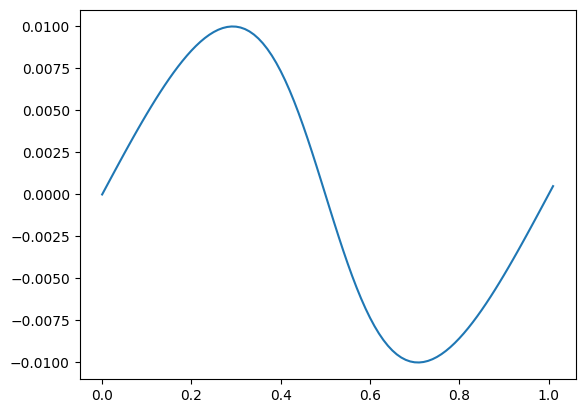

4.299999999999993


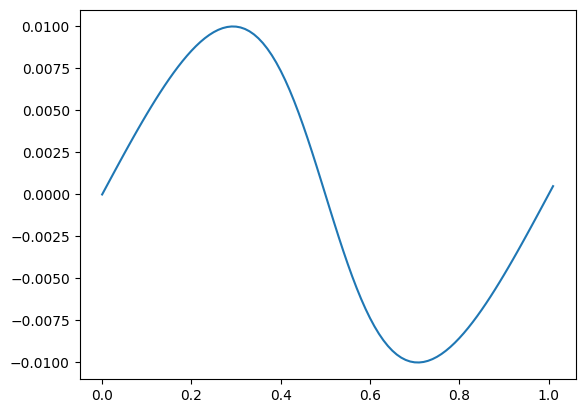

4.3499999999999925


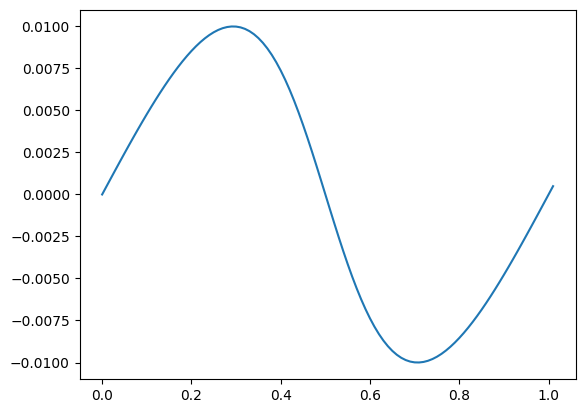

4.399999999999992


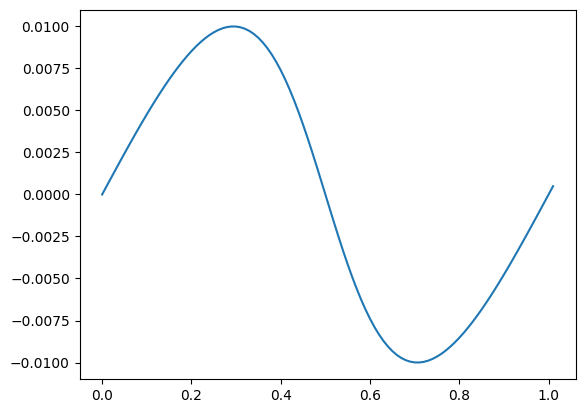

4.449999999999992


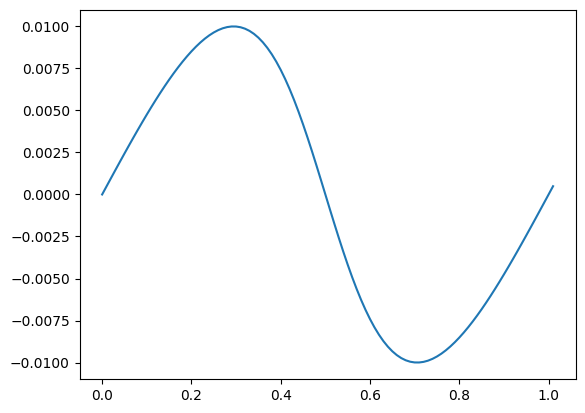

4.499999999999992


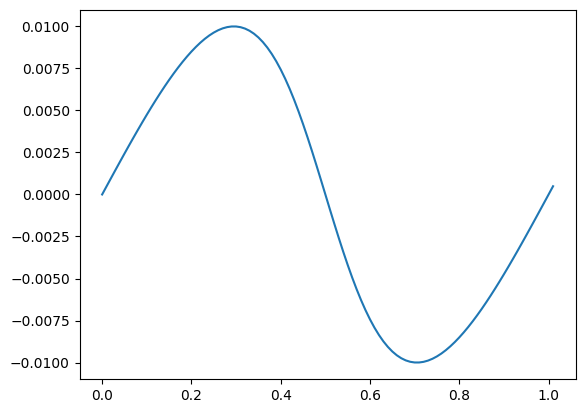

4.549999999999992


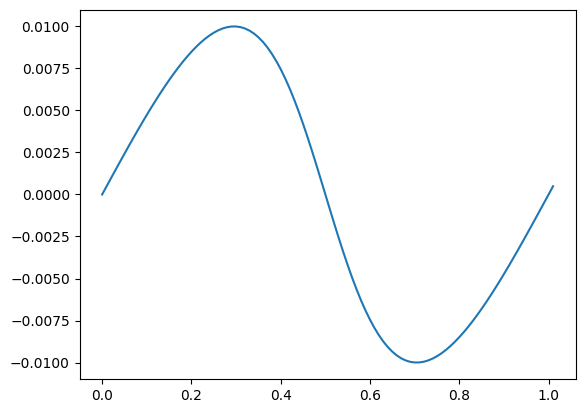

4.599999999999992


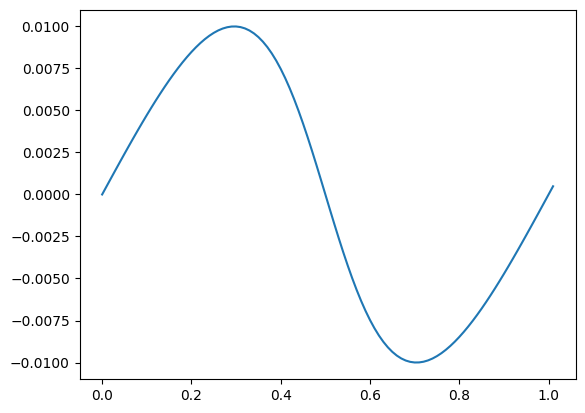

4.6499999999999915


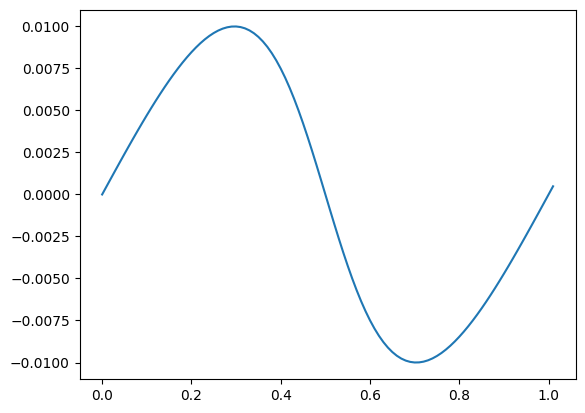

4.699999999999991


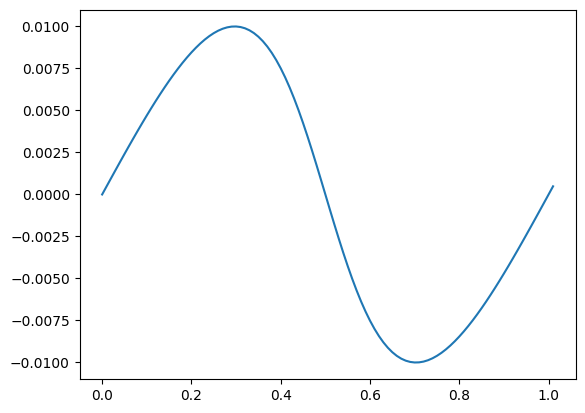

4.749999999999991


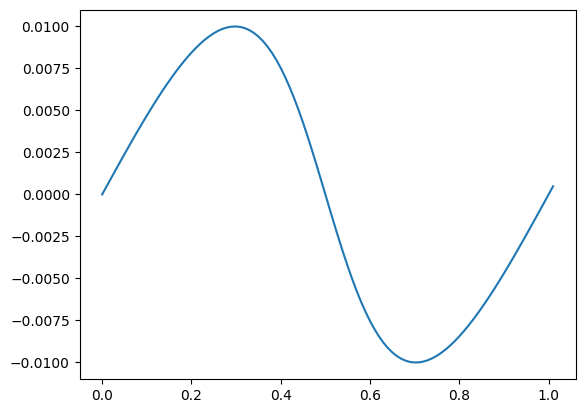

4.799999999999991


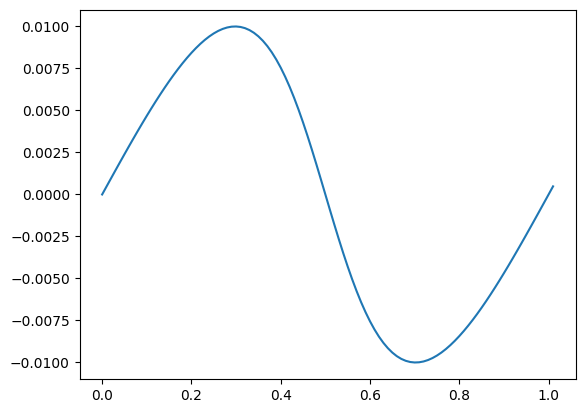

4.849999999999991


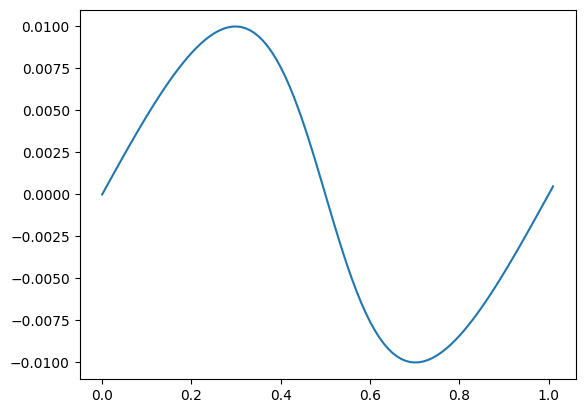

4.899999999999991


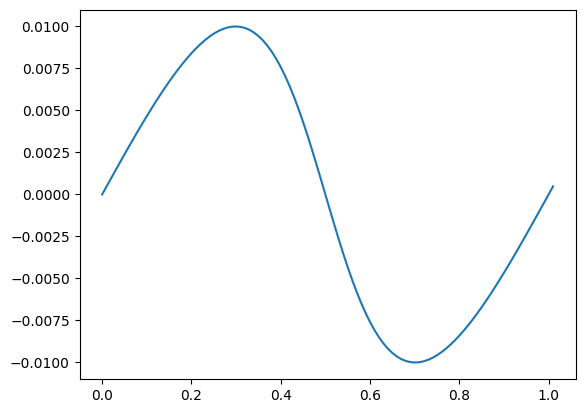

4.94999999999999


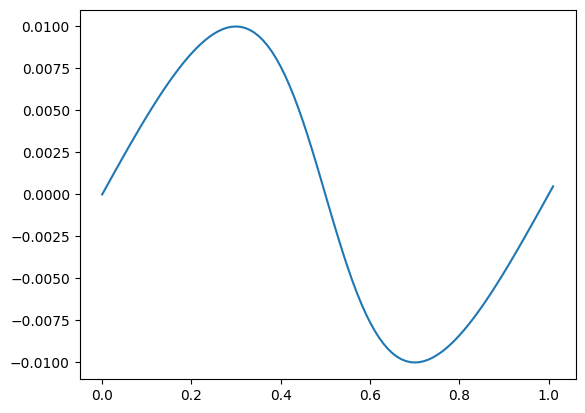

4.99999999999999


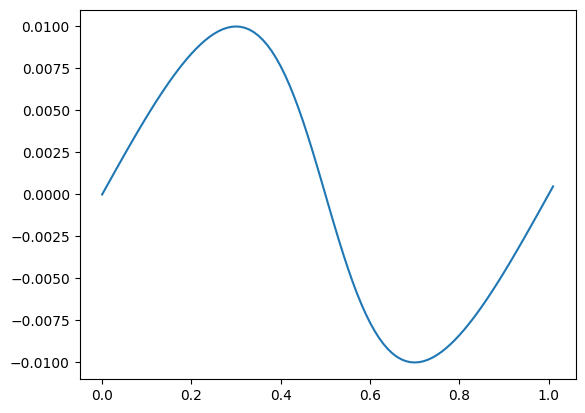

5.04999999999999


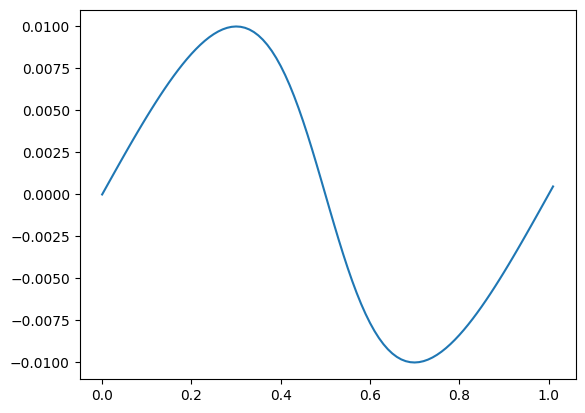

5.09999999999999


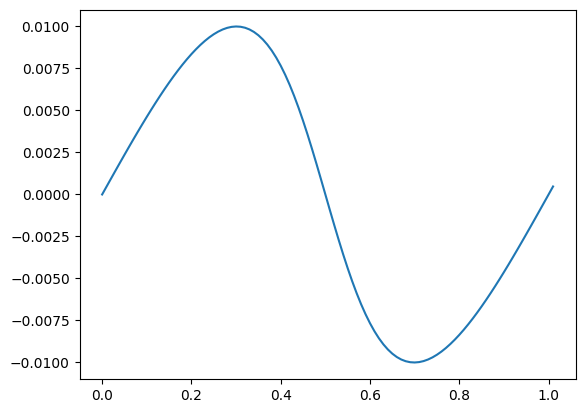

5.14999999999999


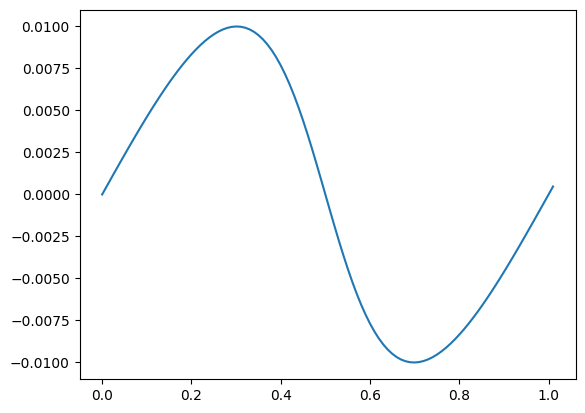

5.1999999999999895


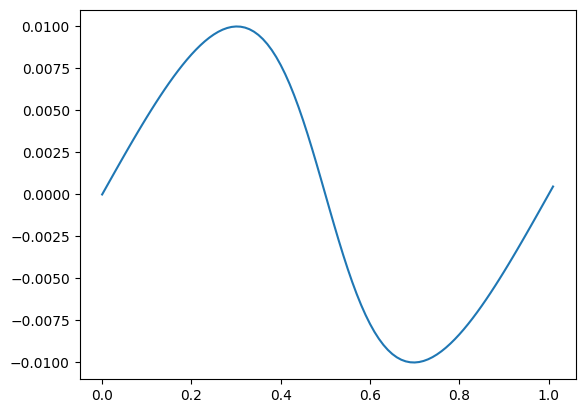

5.249999999999989


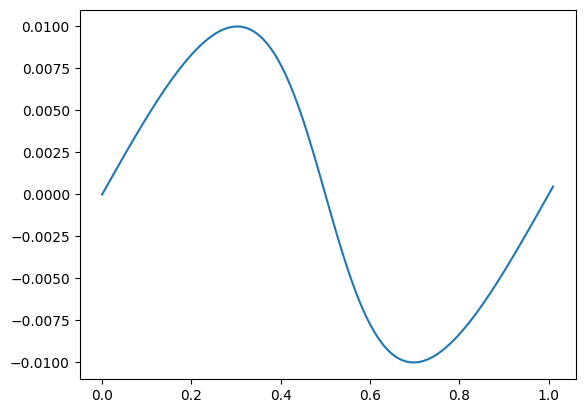

5.299999999999989


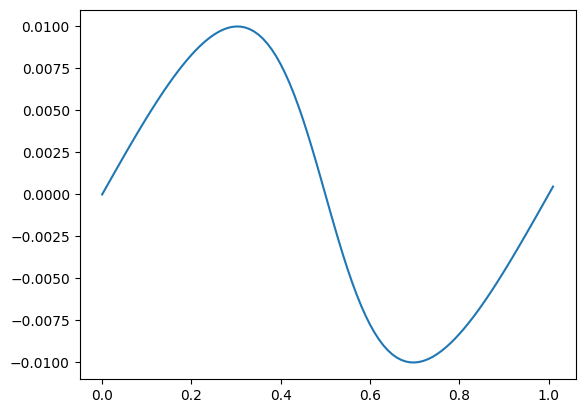

5.349999999999989


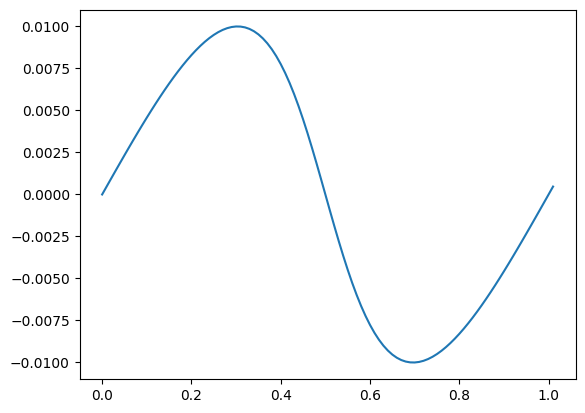

5.399999999999989


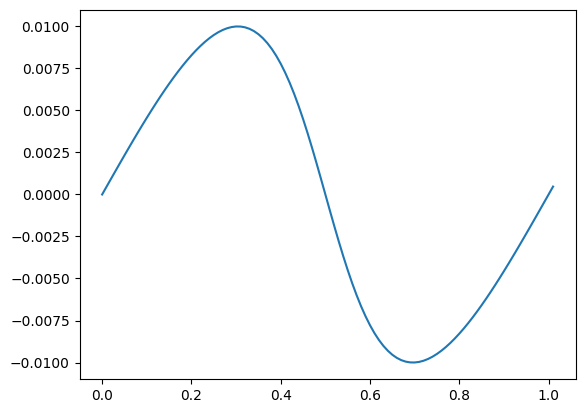

5.449999999999989


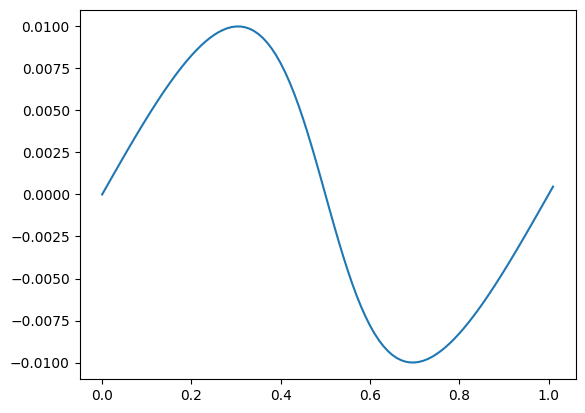

5.4999999999999885


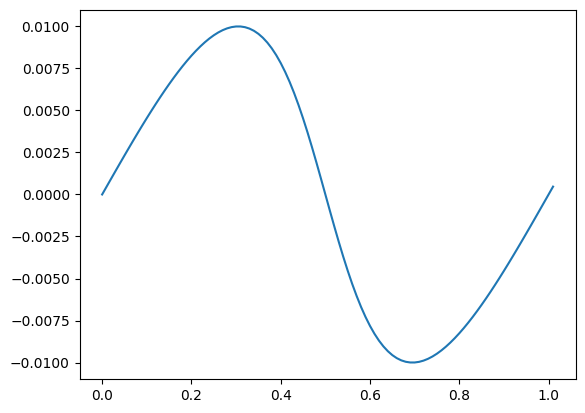

5.549999999999988


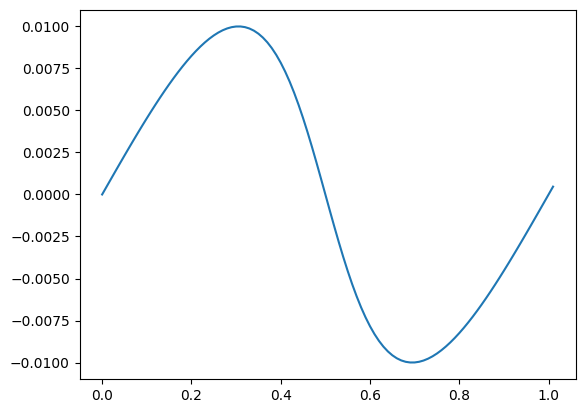

5.599999999999988


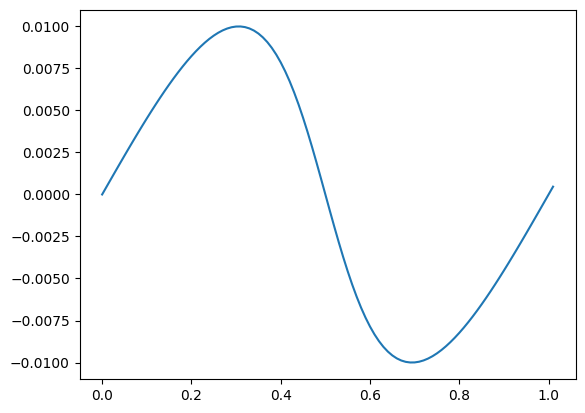

5.649999999999988


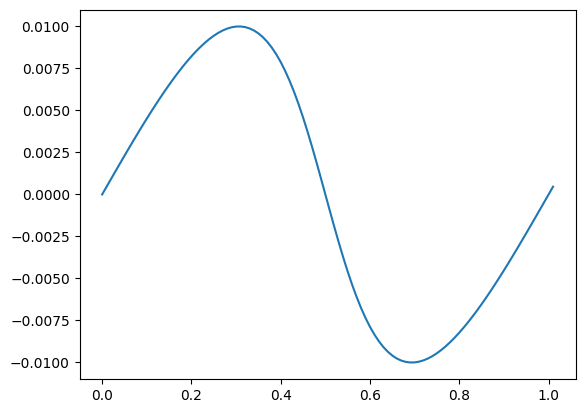

5.699999999999988


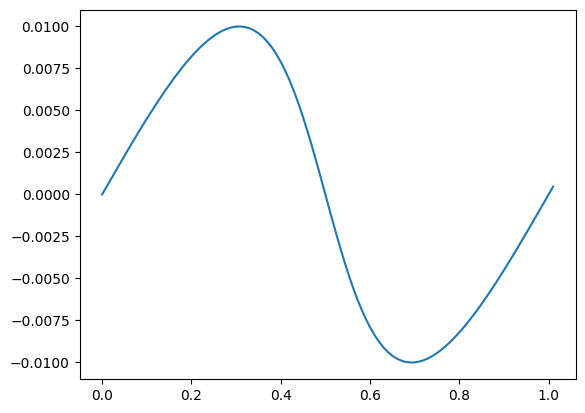

5.749999999999988


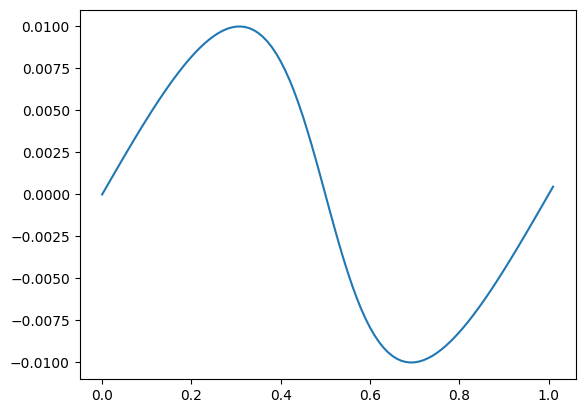

5.799999999999987


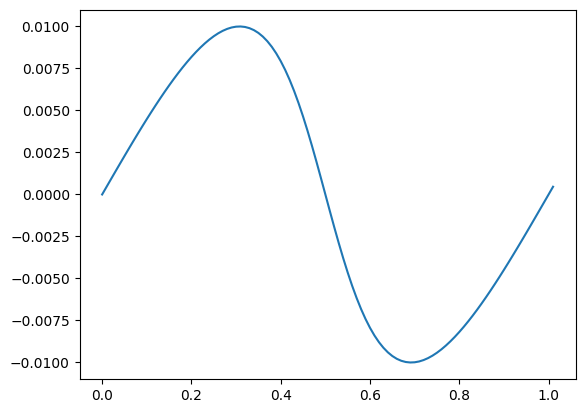

5.849999999999987


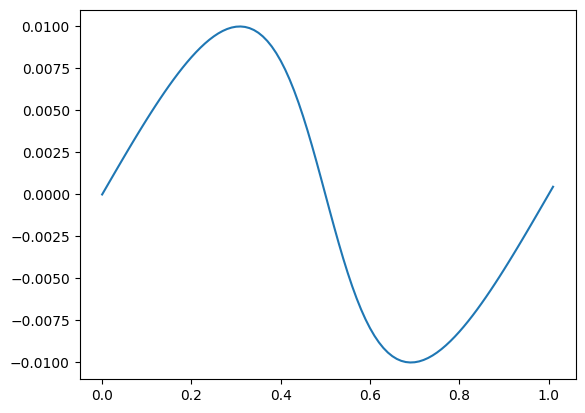

5.899999999999987


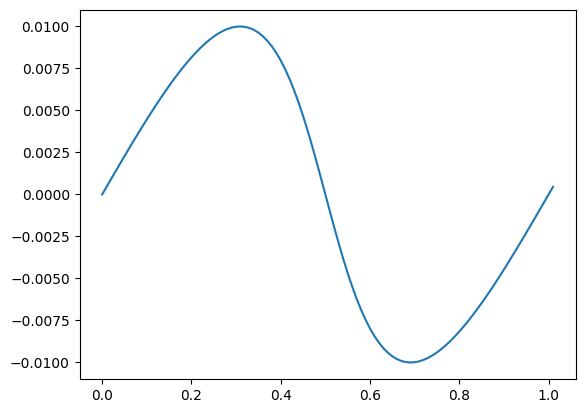

5.949999999999987


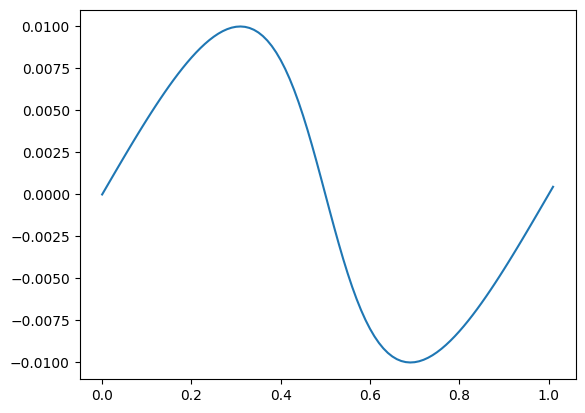

5.999999999999987


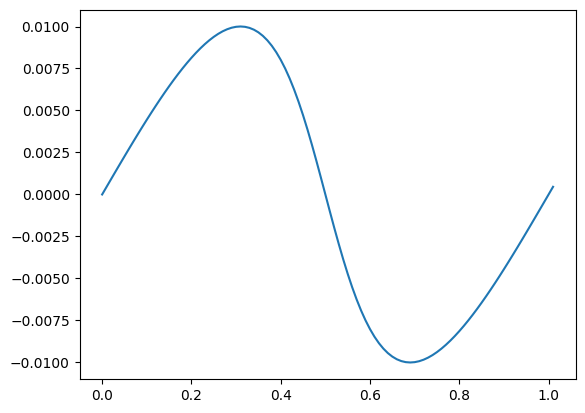

6.0499999999999865


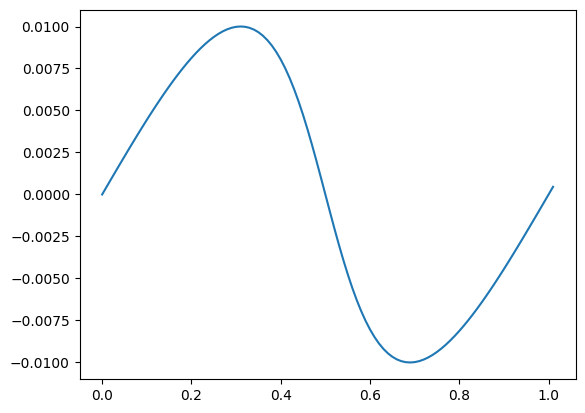

6.099999999999986


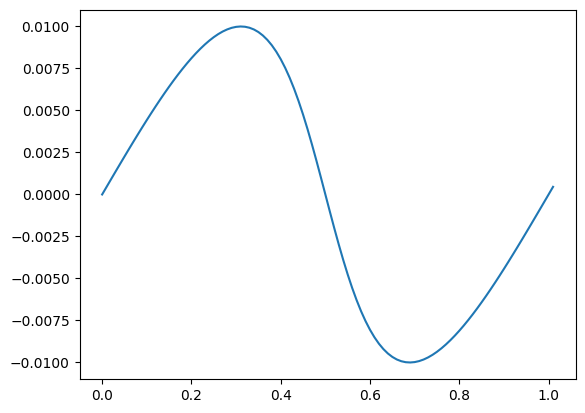

6.149999999999986


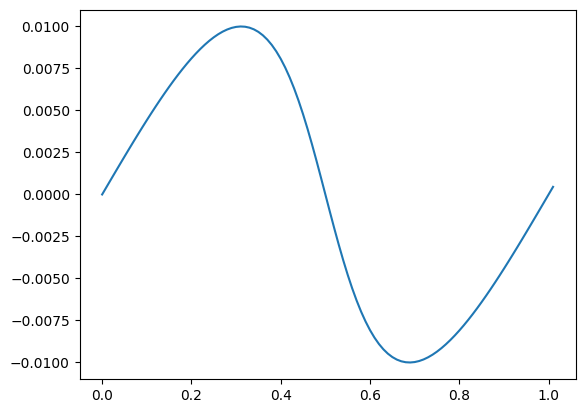

6.199999999999986


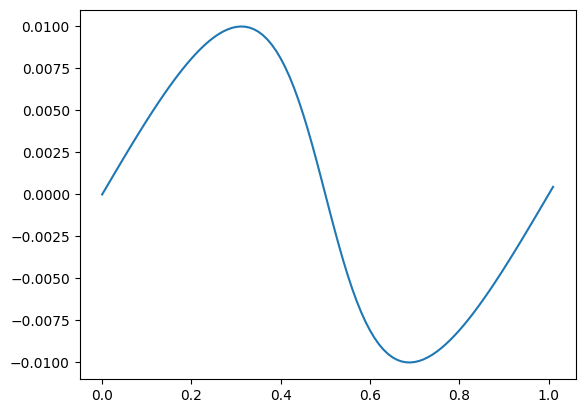

6.249999999999986


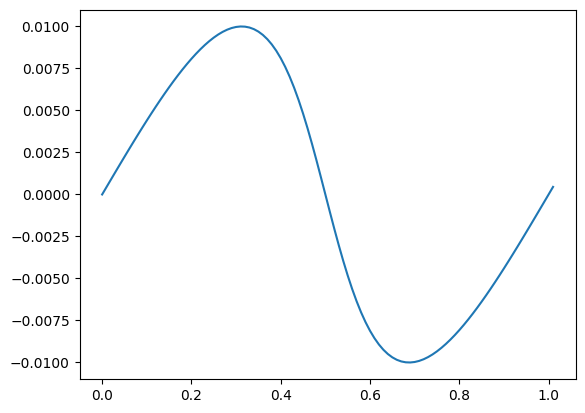

6.299999999999986


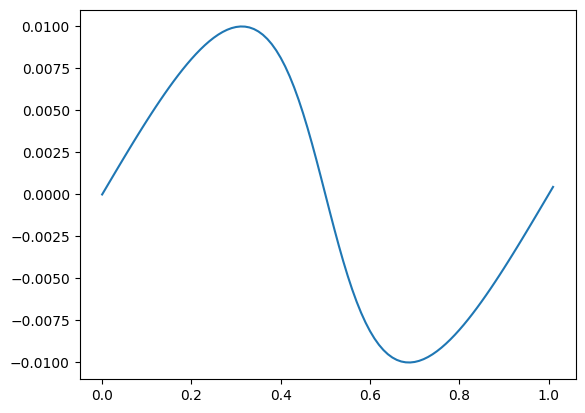

6.349999999999985


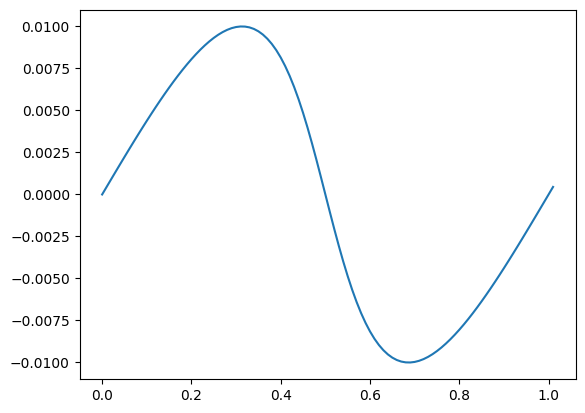

6.399999999999985


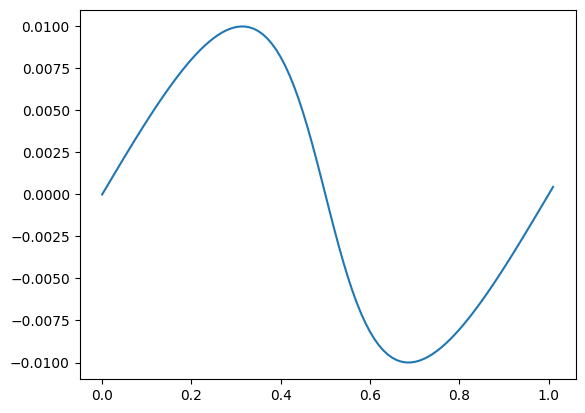

6.449999999999985


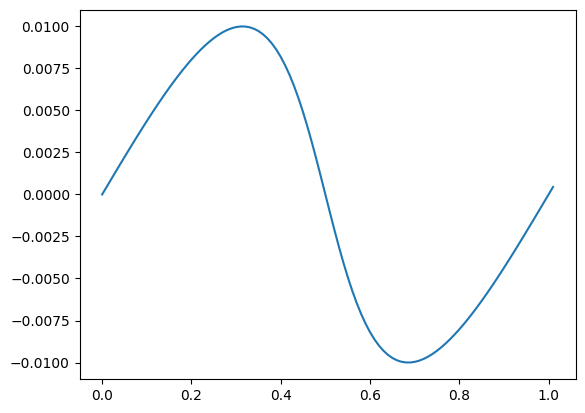

6.499999999999985


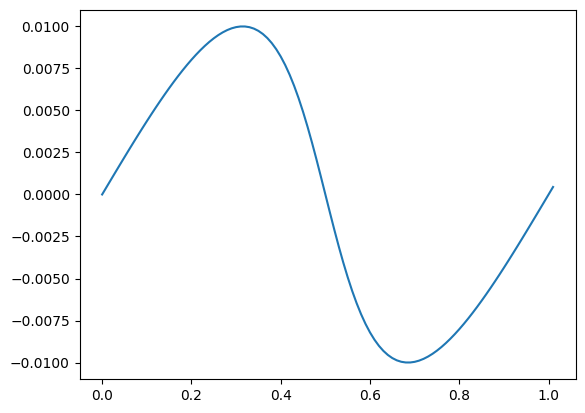

6.549999999999985


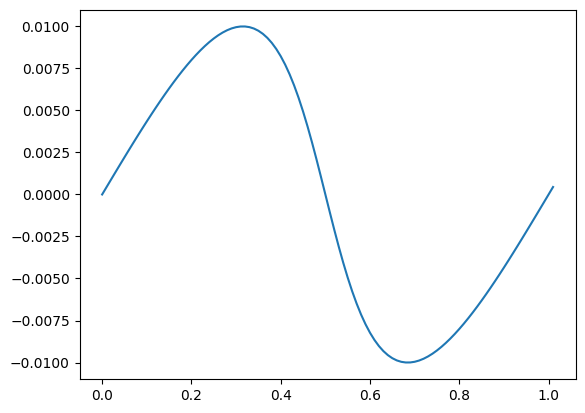

6.5999999999999845


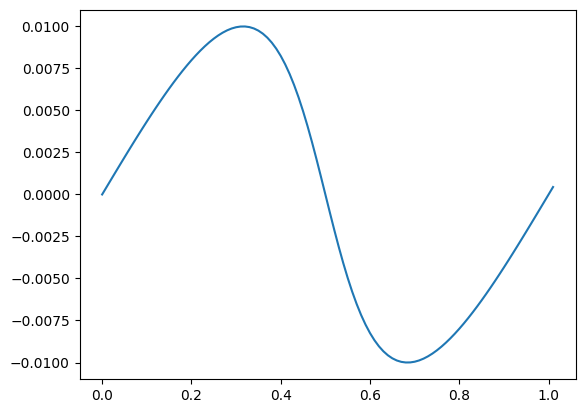

6.649999999999984


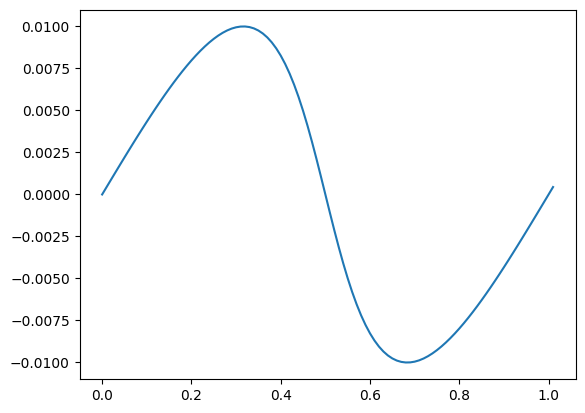

6.699999999999984


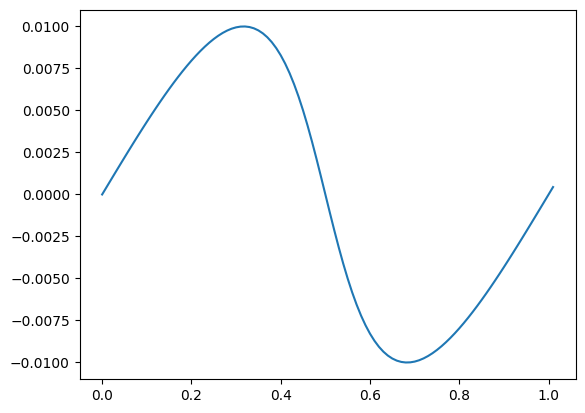

6.749999999999984


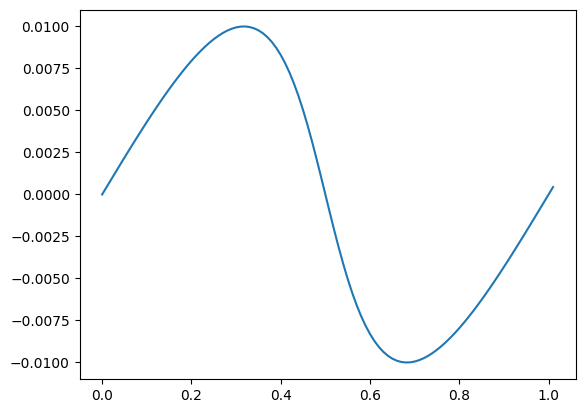

6.799999999999984


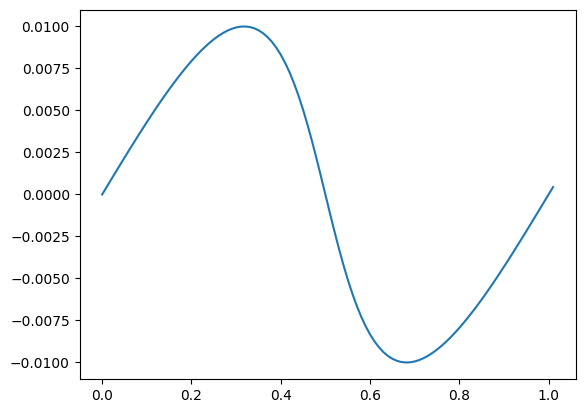

6.849999999999984


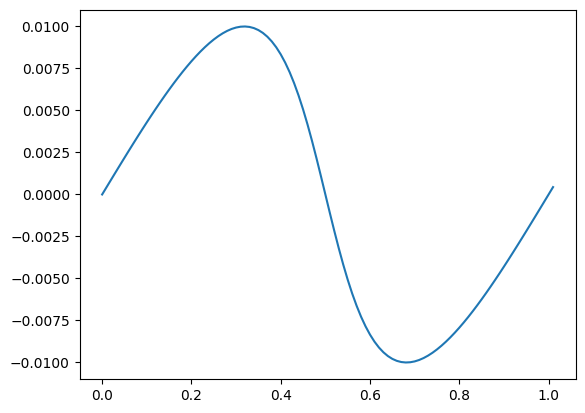

6.8999999999999835


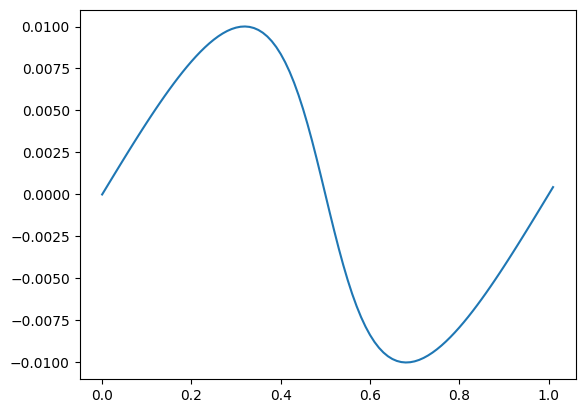

6.949999999999983


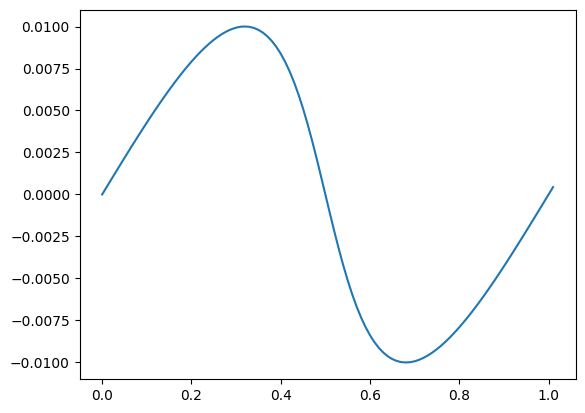

6.999999999999983


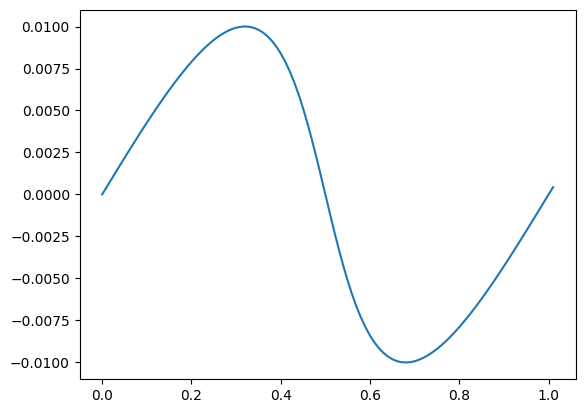

7.049999999999983


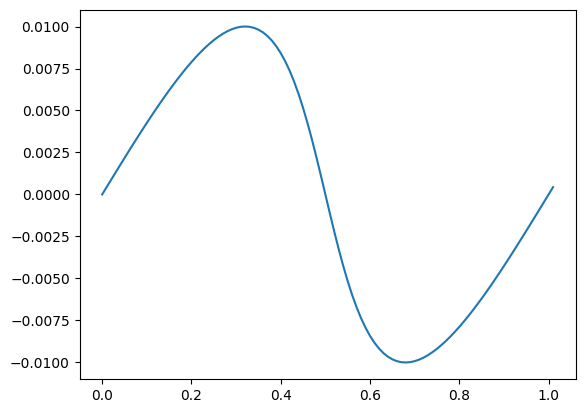

7.099999999999983


KeyboardInterrupt: 

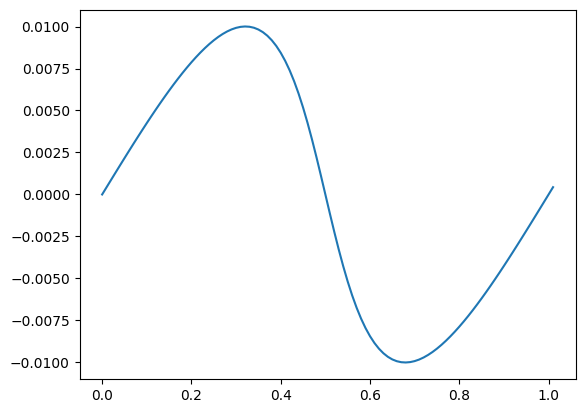

In [1]:
import numpy as np
import matplotlib.pyplot as plt

xstart=0
xstop =1
tstop = 20.0
N=100

dx = (xstop-xstart)/(N)
dt = 0.05 # satifies CFL condition

#creating xarr with an extra ghost point at the end
xarr = np.linspace(xstart,xstop+dx,num=N+2)

#initial velocity
v0 = 0.01*np.sin(2.0*np.pi*xarr)

#define half step and full step to store the data
vhalf = np.zeros(N+1)
v1    = np.zeros(N+2)

time=0.0
#start time loop
while (time <= tstop):
    #calculate half step
    vhalf=0.5*(v0[:-1]+v0[1:])-(dt/(4*dx))*(v0[1:]**2-v0[:-1]**2)
    #calculate the full step
    v1[1:-1]=v0[1:-1]-(dt/(2*dx))*(vhalf[1:]**2-vhalf[:-1]**2)
    
    #apply periodic boundary conditions
    v1[0]=v1[-2]
    v1[-1]=v1[1]
    
    #march forward
    time=time+dt
    v0=v1
    
    
    if (time%0.1 < 1.0E-1):
        print(time)
        plt.plot(xarr,v0)
        plt.show()